# Imports

https://github.com/AminFiroozi/Trading-Algorithm-Project

In [1071]:
# %pip install -q -r requirements.txt

In [1072]:
import yfinance as yf
import pandas as pd
import numpy as np
from pypfopt import expected_returns, risk_models
from pypfopt.efficient_frontier import EfficientFrontier
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools import add_constant
import plotly.graph_objects as go
from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from datetime import datetime
from dateutil.relativedelta import relativedelta
from typing import Literal
import itertools

# Constants

## Control

In [1073]:
FETCH_DATA = False
PLOT_SERIES = False
PLOT_RESULT = False
PLOT_SPREAD = False

## Market

In [1074]:
RISK_FREE_RATE = 4.0 # percent

## Dataset

In [ ]:
START_DATE = "2024-01-01"
END_DATE = "2026-01-01"

# TOP_50 = ["BTC", "ETH", "XRP", "TRX", "LTC"]
SELECTED_TICKERS = ["BTC", "ETH", "LINK", "DOGE", "LTC"]
# SELECTED_TICKERS = ["BTC", "ETH", "SHIB", "ENA", "LTC"]

## Mean-Reversion Bot

In [1076]:
MR_MODE: Literal["explore", "exploit"] = "exploit"
TOTAL_COMBINATIONS = 100

## Martingale Bot

In [1077]:
MAX_LEVELS = 10
INITIAL_ASSET = 1000
MARTINGALE_K = 2.0
TP_PERCENT = 2.5 / 100 # 2.5%
ANCHOR: Literal["Body", "Shadows"] = "Body"

## ADX Bot

In [1078]:
THETA_ADX = 25
ADX_LOOKBACK = 14
SMA_SHORT_LB = 20
SMA_LONG_LB = 50
RSI_LOOKBACK = 14

RETURN = 'Return'
PLUS_DM = 'PDM'
MINUS_DM = 'MDM'
TR = 'TR'
ATR = 'ATR'
SMA_PLUS_DM = 'SMA+DM'
SMA_MINUS_DM = 'SMA-DM'
PLUS_DI = 'PDI'
MINUS_DI = 'MDI'
DX = 'DX'
ADX = 'ADX'
MARKET_STATE = 'MARKET_STATE'
SMA_SHORT = 'SMA_SHORT'
SMA_LONG = 'SMA_LONG'
SMA_SIGNAL = 'SMA_SIGNAL'
SMA_CROSSOVER = 'SMA_CROSSOVER'
GAIN = 'GAIN'
LOSS = 'LOSS'
AVERAGE_GAIN = 'AVERAGE_GAIN'
AVERAGE_LOSS = 'AVERAGE_LOSS'
RS = 'RS'
RSI = 'RSI'
RSI_SIGNAL = 'RSI_SIGNAL'
RSI_CROSSOVER = 'RSI_CROSSOVER'
FINAL_STRATEGY = 'FINAL_STRATEGY'
POSITION = 'POSITION'
STRATEGY_RETURN = 'strategy_return'
PORTFOLIO = 'portfolio'
MARKET_RETURN = 'MARKET_RETURN'

## Routes

In [1079]:
TICKERS_DIR = "tickers"
PLOTS_DIR = "plots"

# Configuration

In [1080]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

# Functions

## Fetching data

In [1081]:
def fetch_data(
    ticker, 
    start: str = START_DATE, 
    end: str = END_DATE
) -> pd.DataFrame:
    filename = os.path.join(TICKERS_DIR, "1H", f"{ticker}USDT_1h.csv")
    df_full = pd.read_csv(filename)
    df_full = df_full.rename(columns={'timestamp': 'Date'})
    df_full = df_full.rename(columns={'volume_from': 'volume'})
    
    df_full['Date'] = pd.to_datetime(df_full['Date'])
    start_ts = pd.to_datetime(start)
    end_ts = pd.to_datetime(end)

    mask = (df_full['Date'] >= start_ts) & (df_full['Date'] <= end_ts)
    df = df_full.loc[mask].copy()
    
    df['Date'] = pd.to_datetime(df['Date'])
    # df = df.set_index('Date')
    df = df.sort_values('Date')
    
    df_1h = df.copy()
    df_1h = df_1h.set_index('Date')
    df_1d = df_1h.resample('D', closed='left', label='left').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    })
    
    df_1d = df_1d.rename(columns={
        'open': 'Open',
        'close': 'Close',
        'low': 'Low',
        'high': 'High',
        'volume': 'Volume',
    })
    df_1d = df_1d.dropna()
    df_1d = df_1d.reset_index()
    df_1d = df_1d.reset_index(drop=True)
    return df_1d

In [1082]:
def fetch_from_yfinance(ticker: str, route: str, start_date, end_date, fetch: bool=True):
    if fetch:
        s = ticker.upper().strip()
        yahoo_format = s if s.endswith("-USD") else f"{s}-USD"
        
        df1 = yf.download(
            tickers=yahoo_format,
            start=start_date,
            end=end_date,
            auto_adjust=False
        )
        df2 = yf.download(
            tickers=ticker,
            start=start_date,
            end=end_date,
            auto_adjust=False
        )
        
        if len(df1) > 0:
            df = df1
        if len(df2) > 0:
            df = df2
            
        df.to_csv(route)
        df = pd.read_csv(route, skiprows=[1, 2], header=0)
        df = df.rename(columns={'Price': 'Date'})
        df = df.set_index('Date')
        df.to_csv(route)
    else:
        df = pd.read_csv(route)
    return df

In [1083]:
def filter_ticker(ticker, start: str, end: str):
    filename = os.path.join(TICKERS_DIR, f"{ticker}.csv")
    # df_full = fetch_from_yfinance(ticker, filename, START_DATE, END_DATE, FETCH_DATA)
    df_full = fetch_data(ticker, START_DATE, END_DATE)
    
    df_full['Date'] = pd.to_datetime(df_full['Date'])
    start_ts = pd.to_datetime(start)
    end_ts = pd.to_datetime(end)

    mask = (df_full['Date'] >= start_ts) & (df_full['Date'] <= end_ts)
    df = df_full.loc[mask].copy()
    df = df.reset_index()
    df = df.drop(columns=['index'])
    return df

## Report

In [1084]:
def max_drawdown(portfolio):
    portfolio_values = portfolio
    running_max = portfolio_values.cummax()
    drawdown = (portfolio_values - running_max) / running_max
    return drawdown.min() * 100

In [1085]:
def sortino_ratio(strategy_returns, risk_free_rate: float = RISK_FREE_RATE, target_return=0):
    mean_return_annual = strategy_returns.mean() * 252
    
    downside_returns = strategy_returns[strategy_returns < target_return]
    
    volatility = downside_returns.std() * np.sqrt(252)
    
    if volatility == 0:
        SORTINO_RATIO = np.nan
    else:
        SORTINO_RATIO = (mean_return_annual - risk_free_rate) / volatility
    
    return SORTINO_RATIO

In [1086]:
def sharpe_ratio(strategy_returns, risk_free_rate: float = RISK_FREE_RATE):
    mean_return = strategy_returns.mean() * 252

    volatility = strategy_returns.std() * np.sqrt(252)

    if volatility == 0:
        SHARPE_RATIO = np.nan
    else:
        SHARPE_RATIO = (mean_return - risk_free_rate) / volatility
        
    return SHARPE_RATIO

In [1087]:
def time_underwater(df):
    price_series = df['Close']
    
    running_max = price_series.cummax()
    drawdown = (price_series - running_max) / running_max
    
    trough_idx = drawdown.idxmin()
    
    prices_before_trough = price_series.loc[:trough_idx]
    if len(prices_before_trough) == 0:
        return 0
    
    peak_idx = prices_before_trough.idxmax()
    peak_price = prices_before_trough.max()
    
    prices_after_trough = price_series.loc[trough_idx:]
    
    recovery_idx = None
    for idx in prices_after_trough.index:
        if price_series.loc[idx] > peak_price:
            recovery_idx = idx
            break
    
    if recovery_idx is None:
        return len(df) - peak_idx
    
    return recovery_idx - peak_idx

In [1088]:
def profit_factor(trades):
    losses = 0
    profits = 0
    for trade in trades:
        if trade['pnl_pct'] >= 0:
            profits += trade['pnl_pct']
        else:
            losses -= trade['pnl_pct']
    # print(f"{profits} / {losses}")
    if losses == 0:
        return profits / 1
    return profits / losses

In [1089]:
def grid_efficiency(trades):
    successful_resets = 0
    failure_resets = 0
    for trade in trades:
        if trade['pnl_pct'] >= 0:
            successful_resets += 1
        else:
            failure_resets += 1
    if failure_resets == 0:
        return successful_resets / 1
    return successful_resets / failure_resets

In [1090]:
def calculate_performance_metrics(df, period_name="All"):
    max_dd = max_drawdown(df['portfolio'])
    sharpe = sharpe_ratio(df['strategy_return'])
    sortino = sortino_ratio(df['strategy_return'])
    total_return = ((df['portfolio'].iloc[-1] / df['portfolio'].iloc[0]) - 1) * 100
    underwater_time = time_underwater(df)
    
    print(f"\n{'='*60}")
    print(f"PERFORMANCE REPORT - {period_name}")
    print(f"{'='*60}")
    print(f"Period:           {df['Date'].iloc[0].date()} to {df['Date'].iloc[-1].date()}")
    print(f"Max Drawdown:     {max_dd:.2f}%")
    print(f"Sharpe Ratio:     {sharpe:+.3f}")
    print(f"Sortino Ratio:    {sortino:+.3f}")
    print(f"Total Return:     {total_return:+.3f}%")
    print(f"Underwater Time:  {underwater_time:+.3f}%")
    
    return {
        'period': period_name,
        'start_date': df['Date'].iloc[0],
        'end_date': df['Date'].iloc[-1],
        'max_drawdown': max_dd,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'total_return': total_return,
        'underwater_time': underwater_time
    }

In [1164]:
def report_martingale(df, trades):
    martingale_df = df.copy()
    martingale_df['YearMonth'] = martingale_df['Date'].dt.to_period('M')
    months = martingale_df['YearMonth'].unique()
    months = sorted(months)
    # for month in months:
    #     month_mask = martingale_df['YearMonth'] == month
    #     month_df = martingale_df[month_mask].copy()
        
    #     if len(month_df) > 1:
    #         calculate_performance_metrics(
    #             month_df, 
    #             f"MONTH {month.strftime('%Y-%m')}"
    #         )
    
    print('='*60)
    print("Total result:")
    print(f"Max Drawdown:    {max_drawdown(martingale_df['portfolio']):.2f}%")
    print(f"Sharpe Ratio:    {sharpe_ratio(martingale_df['strategy_return']):+.3f}")
    print(f"Sortino Ratio:   {sortino_ratio(martingale_df['strategy_return']):+.3f}")
    print(f"Strategy Return: {((martingale_df['portfolio'].iloc[-1] / martingale_df['portfolio'].iloc[0]) - 1) * 100:+.3f}%")
    print(f"Time Underwater: {time_underwater(martingale_df)}")
    print(f"Profit Factor:   {profit_factor(trades):.2f}")
    print(f"Grid Efficiency: {grid_efficiency(trades):.2f}")

In [1092]:
def grid_efficiency(trades):
    successful_resets = 0
    failure_resets = 0
    for trade in trades:
        if trade['pnl_pct'] >= 0:
            successful_resets += 1
        else:
            failure_resets += 1
    if failure_resets == 0:
        return successful_resets / 1
    return successful_resets / failure_resets

In [1093]:
def report_adx(df):
    print("Total result:")
    print(f"Max Drawdown:    {max_drawdown(df['portfolio']):.2f}%")
    print(f"Sharpe Ratio:    {sharpe_ratio(df['strategy_return']):+.3f}")
    print(f"Sortino Ratio:   {sortino_ratio(df['strategy_return']):+.3f}")
    print(f"Strategy Return: {((df['portfolio'].iloc[-1] / df['portfolio'].iloc[0]) - 1) * 100:+.3f}%")

## Stationary Tests

In [1094]:
def adf_test(ticker, df, column='Close'):
    if df is None or df.empty or column not in df.columns:
        return {"Ticker": ticker, "Error": "Missing Data"}

    series = df[column].dropna()
    
    if len(series) < 20:
        return {"Ticker": ticker, "Error": f"Insufficient data points: {len(series)}"}

    result = adfuller(series, autolag='AIC')
    
    adf_output = {
        "Ticker": ticker,
        "ADF Statistic": round(result[0], 4),
        "p-value": round(float(result[1]), 4),
        "Stationary": result[1] < 0.05,
        "Lags Used": result[2],
        "Observations": result[3]
    }
    
    return adf_output

In [1095]:
def hurst_exponent(series, q=2.0, max_lag=None, min_lag=2):
    series = np.asarray(series, dtype=float)
    n = len(series)

    if max_lag is None:
        max_lag = n // 4
    if max_lag <= min_lag:
        raise ValueError("max_lag must be > min_lag")

    # Lags
    lags = np.arange(min_lag, max_lag)

    # K_q values for each lag
    K = np.zeros_like(lags, dtype=float)

    for i, lag in enumerate(lags):
        diffs = np.abs(series[lag:] - series[:-lag])
        K[i] = np.mean(diffs ** q)

    # Fit log–log to estimate slope
    log_lags = np.log(lags)
    log_K = np.log(K)

    slope, _ = np.polyfit(log_lags, log_K, 1)

    Hurst = slope / q
    
    return Hurst

In [1096]:
def half_life(series):
    series = series.dropna()
    
    if len(series) < 10:
        print("For half-life series must be longer than 10 values")
        return np.nan
    
    # Create lagged series
    price_lag = series.shift(1)
    price_diff = series - price_lag
    
    # Remove NaN values
    valid_data = pd.concat([price_lag, price_diff], axis=1).dropna()
    X = add_constant(valid_data.iloc[:, 0])
    y = valid_data.iloc[:, 1]
    
    # Perform OLS regression
    try:
        model = OLS(y, X)
        results = model.fit()
        
        beta = results.params.iloc[1]
        
        half_life = -np.log(2) / np.log(1 + beta) if (1 + beta) > 0 else np.nan
        
        return half_life
    except Exception as e:
        print(f"Error occured while calculating half life: ${e}")
        return np.nan

In [1097]:
def johansen_test(df_combined, det_order=0, k_ar_diff=1):
    df_clean = df_combined.dropna()
    
    if df_clean.shape[1] < 2:
        print("Need at least 2 series for Johansen test.")
        return None

    result = coint_johansen(df_clean, det_order, k_ar_diff)
    
    traces = result.lr1
    cvts = result.cvt
    eigenvalues = result.eig
    
    summary = []
    for i in range(len(traces)):
        is_cointegrated = traces[i] > cvts[i, 1]
        summary.append({
            "Rank": i + 1,
            "Trace Stat": round(traces[i], 4),
            "CV 95%": round(cvts[i, 1], 4),
            "Significant": is_cointegrated
        })
    
    return pd.DataFrame(summary), result.evec[:, 0]

## Plotting

In [1098]:
def store_series_plot(df, ticker: str, route: str = PLOTS_DIR, save: bool = True):
    if not os.path.exists(route):
        os.makedirs(route)
        
    x_axis = df['Date'] if 'Date' in df.columns else df.index
        
    fig = go.Figure(data=[go.Candlestick(
        x=x_axis,
        open=df['Open'],
        high=df['High'],
        low=df['Low'],
        close=df['Close'],
    )])

    fig.update_layout(
        xaxis_title='Date',
        yaxis_title='Price',
        xaxis_rangeslider_visible=False,
        template='plotly_white',
        height=900,
        width=1600,
        showlegend=False
    )
    
    save_path = os.path.join(route, f"{ticker}.png")
    if save:
        fig.write_image(save_path)
    else:
        fig.show()

In [1099]:
def plot_spread_candlestick(group, weights, dfs, folder="plots"):
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Open']  = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    
    spread_high = 0
    spread_low = 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            spread_high += dfs[ticker]['High'] * weights[i]
            spread_low  += dfs[ticker]['Low'] * weights[i]
        else:
            # If weight is negative, the asset's 'Low' contributes to the spread's 'High'
            spread_high += dfs[ticker]['Low'] * weights[i]
            spread_low  += dfs[ticker]['High'] * weights[i]
            
    spread_df['High'] = spread_high
    spread_df['Low']  = spread_low
    
    ticker_name = f"Spread_{'_'.join(group)}"
    store_series_plot(spread_df, ticker_name, folder)

In [1100]:
def plot_overlay_normalized_candlesticks(group, dfs, ticker_name, folder=PLOTS_DIR):
    fig = go.Figure()

    # Distinct color pairs for up/down candles per ticker
    color_pairs = [
        {'inc': '#26a69a', 'dec': '#ef5350'}, # Teal / Red
        {'inc': '#2196f3', 'dec': '#f44336'}, # Blue / Bright Red
        {'inc': '#9c27b0', 'dec': '#e91e63'}, # Purple / Pink
        {'inc': '#ff9800', 'dec': '#795548'}, # Orange / Brown
        {'inc': '#4caf50', 'dec': '#ffeb3b'}  # Green / Yellow
    ]

    for i, ticker in enumerate(group):
        if ticker not in dfs:
            continue
            
        df = dfs[ticker].copy()
        
        # 1. Normalization: Divide all OHLC columns by the first Close price
        base_price = df['Close'].iloc[0]
        df_norm = df[['Open', 'High', 'Low', 'Close']] / base_price
        
        # 2. Select colors for this specific ticker
        colors = color_pairs[i % len(color_pairs)]
        
        # 3. Add the trace
        fig.add_trace(go.Candlestick(
            x=df.index,
            open=df_norm['Open'],
            high=df_norm['High'],
            low=df_norm['Low'],
            close=df_norm['Close'],
            name=f"{ticker} (Norm)",
            increasing_line_color=colors['inc'],
            decreasing_line_color=colors['dec'],
            increasing_fillcolor=colors['inc'],
            decreasing_fillcolor=colors['dec']
        ))

    # 4. Final Layout Adjustments
    fig.update_layout(
        title=f"Overlay Normalized Candlesticks: {', '.join(group)}",
        xaxis_title="Date",
        yaxis_title="Normalized Price (Base = 1.0)",
        xaxis_rangeslider_visible=False,
        template="plotly_white",
        height=600,
        width=1000,
        # This helps see the different candles if they overlap heavily
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    if not os.path.exists(folder):
        os.makedirs(folder)
        
    save_path = os.path.join(folder, f"Overlay_Normalized_{ticker_name}.png")
    fig.write_image(save_path)
    print(f"Overlay plot saved to {save_path}")

In [1162]:
def plot_trades(df: pd.DataFrame, trades: list, ticker: str, mode: Literal["normal", "anti"] = "normal"):
    df_plot = df.copy()
    df_plot["Date"] = pd.to_datetime(df_plot["Date"])

    ema200 = df_plot["Close"].ewm(span=200, adjust=False).mean()

    fig = go.Figure()

    # (datetime.strptime(df_plot["Date"][0].date(), '%Y-%m-%d') - relativedelta(month=6)).strftime('%Y-%m-%d')
    # train_df = filter_ticker(ticker=ticker, start="2023-07-01", end="2024-01-01")
    train_df = fetch_data(ticker=ticker, start="2023-07-01", end="2024-01-01")
    train_ema200 = train_df["Close"].ewm(span=200, adjust=False).mean()
    
    # ---- Candlesticks ----
    fig.add_trace(go.Candlestick(
        x=train_df["Date"],
        open=train_df["Open"],
        high=train_df["High"],
        low=train_df["Low"],
        close=train_df["Close"],
        name="Price"
    ))
    
    fig.add_trace(go.Candlestick(
        x=df_plot["Date"],
        open=df_plot["Open"],
        high=df_plot["High"],
        low=df_plot["Low"],
        close=df_plot["Close"],
        name="Price"
    ))
    
    # ---- EMA200 ----
    if mode == "anti":
        fig.add_trace(go.Scatter(
            x=train_df["Date"],
            y=train_ema200,
            mode="lines",
            line=dict(dash="dash", color="red"),
            name="EMA200"
        ))
        fig.add_trace(go.Scatter(
            x=df_plot["Date"],
            y=ema200,
            mode="lines",
            line=dict(dash="dash"),
            name="EMA200"
        ))
    
    # Equity curve
    fig.add_trace(go.Scatter(
        x=df_plot["Date"],
        y=df_plot['portfolio'] * (df['Close'].iloc[0] / df_plot['portfolio'].iloc[0]),
        mode="lines",
        opacity=0.5,
        name="Equity"
    ))

    # ---- Trades + Grid Levels ----    
    for idx, t in enumerate(trades):
        open_i = t["trade_open"]
        close_i = t["trade_close"]

        open_time = df_plot["Date"].iloc[open_i]
        close_time = df_plot["Date"].iloc[close_i]

        entry_price = t["open_price"]
        exit_price = t["exit_price"]
        avg_price = t["avg_price"]

        spacing = -t["spacing"] if mode == "normal" else t['spacing']
        levels_filled = t["levels_filled"]
        
        # ---- Average price line ----
        fig.add_trace(go.Scatter(
            x=[open_time, close_time],
            y=[avg_price, avg_price],
            mode="lines",
            line=dict(color="orange", width=2, dash="dash"),
            opacity=0.9,
            showlegend=False
        ))

        # ---- Trade line ----
        fig.add_trace(go.Scatter(
            x=[open_time, close_time],
            y=[avg_price, exit_price],
            mode="lines",
            line=dict(width=2, color="black"),
            opacity=1.0,
            showlegend=False
        ))
        
        # Exit line
        exit_price = avg_price * (1 + TP_PERCENT) if mode == "normal" else exit_price
        fig.add_trace(go.Scatter(
            x=[open_time, close_time],
            y=[exit_price, exit_price],
            mode="lines",
            line=dict(width=1, color="purple"),
            opacity=1.0,
            showlegend=False
        ))

        # ---- Grid levels ----
        levels_to_plot = levels_filled + 1 if mode == "normal" else levels_filled
        Range = range(min(levels_to_plot, MAX_LEVELS + 1)) if mode == "normal" else range(-1, min(levels_to_plot, MAX_LEVELS))
        for lvl in Range:
            level_price = entry_price * (1 + spacing) ** lvl

            fig.add_trace(go.Scatter(
                x=[open_time, close_time],
                y=[level_price, level_price],
                mode="lines",
                line=dict(
                    color="blue" if lvl == 0 else "red" if ((lvl == levels_filled and mode == "normal") or (lvl == MAX_LEVELS)) else "gray",
                    width=1,
                    dash="solid" if lvl == MAX_LEVELS else "dot"
                ),
                opacity=1.0 if lvl == MAX_LEVELS else 0.8,
                showlegend=False
            ))
            
            # if (lvl == (levels_filled if mode == "normal" else levels_filled - 1)):
            #     fig.add_annotation(
            #         x=open_time + (close_time - open_time) / 2,
            #         y=level_price * (0.95 if mode == "normal" else 1.05),
            #         text=f"#{idx}: {t['pnl_pct']:.4f}%",
            #         showarrow=False,
            #         textangle=90,
            #         font=dict(size=12, color="black"),
            #         bgcolor="rgba(255,255,255,0.7)"
            #     )

    fig.update_layout(
        title=f"{ticker} —{' Anti-' if mode == 'anti' else ' '}Martingale Grid Trades",
        xaxis_title="Date",
        yaxis_title="Price",
        template="plotly_white",
        xaxis_rangeslider_visible=False,
        xaxis=dict(type="date"),
        height=800,
        width=1400
    )

    fig.show()


In [1102]:
def plot_portfolio(df):
    df_plot = df.copy()
    df_plot["Date"] = pd.to_datetime(df_plot["Date"])
    plt.figure(figsize=(14, 6))
    plt.plot(df_plot['Date'], df_plot['portfolio'], label='Strategy', linewidth=2, alpha=0.7)
    plt.axhline(y=INITIAL_ASSET, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
    plt.ylabel('Portfolio Value ($)', fontsize=12)
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.grid(True, alpha=0.3)
    plt.show()

# Process data

## Filter data

In [1103]:
dfs = {}
if not os.path.exists(TICKERS_DIR):
    os.makedirs(TICKERS_DIR)
    print(f"Created directory: {TICKERS_DIR}")
tickers = TOP_50 if MR_MODE == "explore" else SELECTED_TICKERS
for ticker in tickers:
    filename = os.path.join(TICKERS_DIR, f"{ticker}.csv")
    try:
        # dfs[ticker] = filter_ticker(ticker, START_DATE, END_DATE)
        dfs[ticker] = fetch_data(ticker, START_DATE, END_DATE)
        store_series_plot(dfs[ticker], ticker, save=PLOT_SERIES)
    except Exception as e:
        print(f"Failed to fetch {ticker}: {e}")

## Calculate parameters

In [1104]:
summary_results = []

for ticker in tickers:
    filename = os.path.join(TICKERS_DIR, f"{ticker}.csv")
    try:
        # df = filter_ticker(ticker, START_DATE, END_DATE)
        # df = fetch_data(ticker, START_DATE, END_DATE)
        df = dfs[ticker]
        res = adf_test(ticker, df)
        res['hurst'] = hurst_exponent(df['Close'])
        res['half_life'] = str(round(half_life(df['Close']), 2))
        summary_results.append(res)
        
    except Exception as e:
        print(f"Failed {ticker}: {e}")
        
summary_df = pd.DataFrame(summary_results)
summary_df.head()

,Ticker,ADF Statistic,p-value,Stationary,Lags Used,Observations,hurst,half_life
0,BTC,-1.12,0.71,False,1,605,0.53,154.67
1,ETH,-1.45,0.56,False,0,606,0.46,70.93
2,LINK,-2.22,0.20,False,11,595,0.42,38.02
3,DOGE,-2.02,0.28,False,7,599,0.51,75.67
4,LTC,-2.45,0.13,False,0,606,0.40,32.94


## Filter tickers with p-value $\le$ 0.05

In [1105]:
stationary_df = summary_df[summary_df['p-value'] <= 0.05].copy()
stationary_df = stationary_df.sort_values(by='p-value')
half_life_df = stationary_df.sort_values(by='half_life')
print("Stationary tickers:", len(stationary_df))
half_life_df

Stationary tickers: 0


,Ticker,ADF Statistic,p-value,Stationary,Lags Used,Observations,hurst,half_life


## Mix series

In [1106]:
found_combinations = []
non_stationary_tickers = summary_df[summary_df['p-value'] > 0.05]['Ticker'].tolist()

total_combinations = TOTAL_COMBINATIONS

for r in [4, 5]:
    if len(found_combinations) >= total_combinations: break
    
    potential_groups = list(itertools.combinations(non_stationary_tickers, r)) 

    for group in potential_groups:
        if len(found_combinations) >= total_combinations: break
        
        combined_data = pd.concat([dfs[t]['Close'] for t in group], axis=1).dropna()
        
        res = coint_johansen(combined_data, det_order=0, k_ar_diff=1)
        
        if res.lr1[0] > res.cvt[0, 1]: 
            weights = res.evec[:, 0] 
            found_combinations.append({
                'group': group,
                'weights': weights,
                'johansen_stat': res.lr1[0]
            })

## Get top combinations

In [1107]:
results_with_hl = []

for item in found_combinations:
    group = item['group']
    weights = item['weights']
    
    spread_series = pd.Series(0, index=dfs[group[0]].index)
    for i, ticker in enumerate(group):
        spread_series += dfs[ticker]['Close'] * weights[i]
        
    if (spread_series < 0).all():
        # print(f"reversing sign of {group}")
        weights = [-w for w in weights]
        spread_series = pd.Series(0, index=dfs[group[0]].index)
        for i, ticker in enumerate(group):
            spread_series += dfs[ticker]['Close'] * weights[i]
    
    if (spread_series < 0).any():
        # print(f"skip {group} because of negative value")
        continue
    
    hl = half_life(spread_series)
    if hl is not np.nan and hl > 1:
        results_with_hl.append({
            'group': group,
            'half_life': hl,
            'spread_series': spread_series,
            'weights': weights
        })

top_combinations = sorted(results_with_hl, key=lambda x: x['half_life'])
for i in range(len(top_combinations)):
    print(f"{str(top_combinations[i]['group']):<40}: {top_combinations[i]['half_life']:.3f}")

## Plot spread series and normalized series

In [1108]:
if PLOT_SPREAD:
    for comb in top_combinations:
        group = comb['group']
        weights = comb['weights']
        ticker_name = "_".join(group)
        plot_overlay_normalized_candlesticks(group, dfs, ticker_name)
        plot_spread_candlestick(group, weights, dfs)

# Strategies

## Mean-Reversion Bot

In [1109]:
def calculate_mean_reversion_params(spread_df, hl_value):
    lookback = int(hl_value * (int(np.ceil(30 / hl_value)) if hl_value < 30 else 2))
    
    ema_range = spread_df['Close'].ewm(span=lookback, adjust=False).mean()
    std_spread = spread_df['Close'].rolling(window=lookback, min_periods=5).std()
    
    return lookback, ema_range, std_spread

In [1110]:
strategy_results = []

for comb in top_combinations[:10]:
    group = comb['group']
    weights = comb['weights']
    hl = comb['half_life']
    
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Open']  = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    
    spread_df['Return'] = spread_df['Close'].pct_change(fill_method=None) * 100
    
    s_high, s_low = 0, 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            s_high += dfs[ticker]['High'] * weights[i]
            s_low  += dfs[ticker]['Low'] * weights[i]
        else:
            s_high += dfs[ticker]['Low'] * weights[i]
            s_low  += dfs[ticker]['High'] * weights[i]
    spread_df['High'], spread_df['Low'] = s_high, s_low
    
    lb, ema, std = calculate_mean_reversion_params(spread_df, hl)
    
    spread_df['std'] = std
    spread_df['ema'] = ema
    spread_df['Date'] = dfs[ticker]['Date']
    
    
    print(f"\nGroup: {'-'.join(group)}")
    print(f"Half-life: {hl:.2f} days")
    print(f"Calculated Lookback: {lb} days")
    print(f"Latest EMA (of Range): {ema.iloc[-1]:.4f}")
    print(f"Latest STD: {std.iloc[-1]:.4f}")
    
    strategy_results.append({
        'group': group,
        'spread_df': spread_df,
        'ema_range': ema,
        'std_spread': std,
        'lookback': lb
    })

In [1111]:
for result in strategy_results:
    # print(result['spread_df'])
    initial_asset = 1000
    df = result['spread_df']
    
    x = 0.01 # Safety ratio 
    result['spread_df']['short_signal1'] = np.where((df['High'] > df['ema'] + df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    result['spread_df']['short_signal2'] = np.where((df['High'] > df['ema'] + 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    
    result['spread_df']['long_signal1'] = np.where((df['Low'] < df['ema'] - df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    result['spread_df']['long_signal2'] = np.where((df['Low'] < df['ema'] - 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    
    result['spread_df']['above_ema'] = np.where(df['Close'] > df['ema'], 1, 0)
    result['spread_df']['below_ema'] = np.where(df['Close'] < df['ema'], 1, 0)
    
    result['spread_df']['ema_long_crossover'] = result['spread_df']['above_ema'].diff()
    result['spread_df']['ema_short_crossover'] = result['spread_df']['below_ema'].diff()
    
    result['spread_df']['short_crossover1'] = result['spread_df']['short_signal1'].diff()
    result['spread_df']['short_crossover2'] = result['spread_df']['short_signal2'].diff()
    
    result['spread_df']['long_crossover1'] = result['spread_df']['long_signal1'].diff()
    result['spread_df']['long_crossover2'] = result['spread_df']['long_signal2'].diff()
    
    current_position = 0
    positions = np.zeros(len(df))

    for i in range(len(df)):
        
        if result['spread_df']['below_ema'].iloc[i] == 1 and current_position < 0:
            current_position = 0
        elif result['spread_df']['above_ema'].iloc[i] == 1 and current_position > 0:
            current_position = 0
        elif result['spread_df']['short_crossover2'].iloc[i] == 1 and result['spread_df']['above_ema'].iloc[i] == 1:
            current_position = -2
        elif result['spread_df']['short_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = -1
        elif result['spread_df']['long_crossover2'].iloc[i] == 1 and result['spread_df']['below_ema'].iloc[i] == 1:  
            current_position = +2
        elif result['spread_df']['long_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = +1
        elif result['spread_df']['ema_long_crossover'].iloc[i] == 1 or result['spread_df']['ema_short_crossover'].iloc[i] == 1:
            current_position = 0
            
        positions[i] = current_position
        
    result['spread_df']['position'] = positions
    
    # ---------------------------------------------------------------------
    
    result['spread_df']['strategy_return'] = result['spread_df']['position'].shift(1) * result['spread_df']['Return'] / 2
    result['spread_df']['strategy_return'] = result['spread_df']['strategy_return'].fillna(0)
    
    portfolio_values = np.zeros(len(df) + 1)
    portfolio_values[0] = initial_asset

    for i in range(len(df)):
        portfolio_values[i + 1] = portfolio_values[i] * (1 + result['spread_df']['strategy_return'].iloc[i] / 100)

    result['spread_df']['portfolio'] = portfolio_values[1:]
    
    result['spread_df']['BNH'] = initial_asset * (1 + result['spread_df']['Return'] / 100).cumprod()
    result['spread_df'].loc[0, 'BNH'] = initial_asset
    
    # ------------------------------------------------------------------------------------------------------
    
    plt.figure(figsize=(14, 6))
    
    plt.plot(df.index, df['BNH'], label='Buy & Hold', linewidth=2, alpha=0.7, color='blue')
    plt.plot(df.index, df['portfolio'], label='Strategy', linewidth=2, alpha=0.7, color='green')
    # plt.plot(df.index, df['ema'], label='ema', linewidth=2, alpha=0.7, color='orange')
    plt.plot(df.index, df['ema'] * (initial_asset / df['ema'].iloc[0]), label='ema', linewidth=2, alpha=0.7, color='black')
    
    plt.axhline(y=initial_asset, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
    plt.ylabel('Portfolio Value ($)', fontsize=12)
    plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')
    # plt.legend(loc='best', fontsize=10)
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.grid(True, alpha=0.3)
    
    # ---------------------------------------------------------------------------------------------------------
    
    ax = plt.gca() # Get current axes
    long1pos = (df['position'] > 0) | (df['position'].shift(1) > 0)
    long2pos = (df['position'] == 2) | (df['position'].shift(1) == 2)
    short1pos = (df['position'] < 0) | (df['position'].shift(1) < 0)
    short2pos = (df['position'] == -2) | (df['position'].shift(1) == -2)
    plt.fill_between(df.index, 0, 1, where=(long1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0F0')
    plt.fill_between(df.index, 0, 1, where=(short1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#F00')
    plt.fill_between(df.index, 0, 1, where=(long2pos), transform=ax.get_xaxis_transform(), alpha=0.3, color='#050')
    plt.fill_between(df.index, 0, 1, where=(short2pos), transform=ax.get_xaxis_transform(), alpha=0.3, color='#500')
    
    # ------------------------------------------------------------------------------------------------
    
    df = result['spread_df']
    df['trade_id'] = (np.sign(df['position']) != np.sign(df['position'].shift())).cumsum()
    
    active_df = df[df['position'] != 0].copy()

    if not active_df.empty:
        temp_df = active_df.reset_index()
        idx_col = temp_df.columns[0]
        
        # 3. Aggregate metadata
        trades = temp_df.groupby('trade_id').agg(
            pos_type=('position', 'first'),
            start_idx=(idx_col, 'first'),
            end_idx=(idx_col, 'last')
        )

        running_total_gain = 1
        
        for t_id, trade in trades.iterrows():
            # --- LAG FIX ---
            start_val = df.loc[trade['start_idx'], 'portfolio']
            try:
                end_val = df.loc[trade['end_idx'] + 1, 'portfolio']
            except:
                end_val = df.loc[trade['end_idx'], 'portfolio']

            actual_trade_return = (end_val / start_val - 1) * 100
            
            # Calculate Running Total (Total Gain from $initial_asset start)
            running_total_gain = (end_val / initial_asset - 1) * 100
            
            # Calculate horizontal center for the label
            mid_point = (trade['start_idx'] + trade['end_idx']) / 2
            
            label1 = f"{actual_trade_return:.2f}%"
            label2 = f"{running_total_gain:.2f}%"
            
            # 4. Placement
            ax.text(mid_point, 0.5, label1, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=7, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
            ax.text(mid_point, -0.15, label2, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=11, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
    
    
    columns_to_drop = [
        'short_crossover2', 'short_crossover1', 'long_crossover1', 'long_crossover2', 
        'short_signal1', 'short_signal2', 'long_signal1', 'long_signal2', 'above_ema', 'below_ema',
        'ema_long_crossover', 'ema_short_crossover', 
        'trade_id'
        ]
    
    result['spread_df'] = result['spread_df'].drop(columns=columns_to_drop)
        
    plt.title(f"Group: {result['group']} / Sharpe Ratio: {sharpe_ratio(result['spread_df']['strategy_return']):.2f} / Max Drawdown: {max_drawdown(result['spread_df']['portfolio']):.2f}% / Return: {(result['spread_df']['portfolio'].iloc[-1] / initial_asset - 1) * 100:.2f}%", fontsize=14, fontweight='bold')
    
# x = strategy_results[0]
# print(x['group'])

In [ ]:
def no_bias_mean_reversion_bot(initial_asset: int = 1000, start_date: str = "2024-01-01", end_date: str | None = None):
    start_dt = pd.to_datetime(start_date)
    if end_date is None:    
        end_dt = start_dt + relativedelta(months=4)
        end_date = end_dt.date().strftime('%Y-%m-%d')
    
    deadline_dt = start_dt + relativedelta(months=1)
    
    train_start_date = start_dt - relativedelta(months=6)
    train_end_date = start_dt - relativedelta(days=1)
    
    # ------------------------------------------------------------------
    
    summary_results = []
    tickers = TOP_50 if MR_MODE == "explore" else SELECTED_TICKERS
    for ticker in tickers:
        try:
            # df = filter_ticker(ticker, train_start_date.date().strftime('%Y-%m-%d'), train_end_date.date().strftime('%Y-%m-%d'))
            df = fetch_data(ticker, train_start_date.date().strftime('%Y-%m-%d'), train_end_date.date().strftime('%Y-%m-%d'))

            res = adf_test(ticker, df)
            res['hurst'] = hurst_exponent(df['Close'])
            res['half_life'] = half_life(df['Close'])
            res['df'] = df
            summary_results.append(res)

        except Exception as e:
            pass
            # print(f"Failed {ticker}: {e}")

    summary_df = pd.DataFrame(summary_results)
    stationary_df = summary_df[summary_df['p-value'] <= 0.05].copy()
    stationary_df = stationary_df.sort_values(by='p-value')
    found_combinations = []
    non_stationary_tickers = summary_df[summary_df['p-value'] > 0.05]['Ticker'].tolist()
    
    # --------------------------------------------------------------------------
    
    dfs = {item['Ticker']: item['df'] for item in summary_results}
    for r in [4, 5]:
        if len(found_combinations) >= TOTAL_COMBINATIONS: break
        
        potential_groups = list(itertools.combinations(non_stationary_tickers, r)) 

        for group in potential_groups:
            if len(found_combinations) >= TOTAL_COMBINATIONS: break
            
            combined_data = pd.concat([dfs[t]['Close'] for t in group], axis=1).dropna()
            
            res = coint_johansen(combined_data, det_order=0, k_ar_diff=1)
            
            if res.lr1[0] > res.cvt[0, 1]: 
                weights = res.evec[:, 0] 
                found_combinations.append({
                    'group': group,
                    'weights': weights,
                    'johansen_stat': res.lr1[0]
                })
                
    # -------------------------------------------------------------------------------------
    
    results_with_hl = []
    for item in found_combinations:
        group = item['group']
        weights = item['weights']
        
        spread_series = pd.Series(0, index=dfs[group[0]].index)
        for i, ticker in enumerate(group):
            spread_series += dfs[ticker]['Close'] * weights[i]
            
        if (spread_series < 0).all():
            weights = [-w for w in weights]
            spread_series = pd.Series(0, index=dfs[group[0]].index)
            for i, ticker in enumerate(group):
                spread_series += dfs[ticker]['Close'] * weights[i]
        
        if (spread_series < 0).any():
            continue
        
        hl = half_life(spread_series)
        
        if hl is not np.nan and hl > 1:
            results_with_hl.append({
                'group': group,
                'half_life': hl,
                'spread_series': spread_series,
                'weights': weights
            })

    # ------------------------------------------------------------------------
    
    if len(results_with_hl) > 0:
        comb = sorted(results_with_hl, key=lambda x: x['half_life'])[0]
    else:
        return {}, start_dt + relativedelta(days=1)
    
    group = comb['group']
    weights = comb['weights']
    hl = comb['half_life']
    dfs = {ticker: fetch_data(ticker, start_date, end_date) for ticker in group}
    # dfs = {ticker: filter_ticker(ticker, start_date, end_date) for ticker in group}
    
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Open']  = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    
    spread_df['Return'] = spread_df['Close'].pct_change(fill_method=None) * 100
    
    s_high, s_low = 0, 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            s_high += dfs[ticker]['High'] * weights[i]
            s_low  += dfs[ticker]['Low'] * weights[i]
        else:
            s_high += dfs[ticker]['Low'] * weights[i]
            s_low  += dfs[ticker]['High'] * weights[i]
    spread_df['High'], spread_df['Low'] = s_high, s_low
    
    if (spread_df['Low'] < 0).any() or len(spread_df) < 5:
        return {}, start_dt + relativedelta(days=1)
    print(spread_df.head())
    
    lb, ema, std = calculate_mean_reversion_params(spread_df, hl)
    
    spread_df['std'] = std
    spread_df['ema'] = ema
    spread_df['Date'] = dfs[ticker]['Date']
    
    # ------------------------------------------------------
    
    result = {
        'group': group,
        'weights': weights,
        'spread_df': spread_df,
        'ema_range': ema,
        'std_spread': std,
        'lookback': lb
    }
    
    df = result['spread_df']
    
    result['spread_df']['coin'] = "*".join(group)
    result['spread_df']['weights'] = "*".join([str(weight) for weight in weights])
    x = 0.00 # Safety ratio 
    y = 0.02 # Safety ratio 
    result['spread_df']['short_signal1'] = np.where((df['Close'] > df['ema'] + df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    result['spread_df']['short_signal2'] = np.where((df['Close'] > df['ema'] + 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    
    result['spread_df']['long_signal1'] = np.where((df['Close'] < df['ema'] - df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    result['spread_df']['long_signal2'] = np.where((df['Close'] < df['ema'] - 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    # result['spread_df']['short_signal1'] = np.where((df['High'] > df['ema'] + df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    # result['spread_df']['short_signal2'] = np.where((df['High'] > df['ema'] + 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    
    # result['spread_df']['long_signal1'] = np.where((df['Low'] < df['ema'] - df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    # result['spread_df']['long_signal2'] = np.where((df['Low'] < df['ema'] - 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    
    result['spread_df']['above_ema'] = np.where(df['Close'] > df['ema'] - y * df['ema'], 1, 0)
    result['spread_df']['below_ema'] = np.where(df['Close'] < df['ema'] + y * df['ema'], 1, 0)
    
    result['spread_df']['ema_long_crossover'] = result['spread_df']['above_ema'].diff()
    result['spread_df']['ema_short_crossover'] = result['spread_df']['below_ema'].diff()
    
    result['spread_df']['short_crossover1'] = result['spread_df']['short_signal1'].diff()
    result['spread_df']['short_crossover2'] = result['spread_df']['short_signal2'].diff()
    
    result['spread_df']['long_crossover1'] = result['spread_df']['long_signal1'].diff()
    result['spread_df']['long_crossover2'] = result['spread_df']['long_signal2'].diff()
    
    # --------------------------------------------------------------------------
    
    current_position = 0
    positions = np.zeros(len(df))

    for i in range(len(df)):
        if result['spread_df']['below_ema'].iloc[i] == 1 and current_position < 0:
            current_position = 0
        elif result['spread_df']['above_ema'].iloc[i] == 1 and current_position > 0:
            current_position = 0
        elif result['spread_df']['ema_long_crossover'].iloc[i] == 1 or result['spread_df']['ema_short_crossover'].iloc[i] == 1:
            current_position = 0
        elif result['spread_df']['short_crossover2'].iloc[i] == 1 and result['spread_df']['above_ema'].iloc[i] == 1:
            current_position = -2
        elif result['spread_df']['short_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = -1
        elif result['spread_df']['long_crossover2'].iloc[i] == 1 and result['spread_df']['below_ema'].iloc[i] == 1:  
            current_position = +2
        elif result['spread_df']['long_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = +1
            
        positions[i] = current_position
        
    result['spread_df']['position'] = positions
    
    closed_after_deadline = result['spread_df'][
        (result['spread_df']['Date'] >= deadline_dt) & 
        (result['spread_df']['position'] == 0)
    ]
    
    if not closed_after_deadline.empty:
        first_close_row = closed_after_deadline.iloc[0]
        new_start_date = first_close_row['Date']
    else:
        new_start_date = result['spread_df']['Date'].iloc[-1]
        
    
    mask = (result['spread_df']['Date'] <= new_start_date)
    result['spread_df'] = result['spread_df'].loc[mask].copy()
    
    # ----------------------------------------------------------------------------------------------
    
    df = result['spread_df']
    
    result['spread_df']['strategy_return'] = result['spread_df']['position'].shift(1) * result['spread_df']['Return'] / 2
    result['spread_df']['strategy_return'] = result['spread_df']['strategy_return'].fillna(0)
    
    portfolio_values = np.zeros(len(df) + 1)
    portfolio_values[0] = initial_asset

    for i in range(len(df)):
        portfolio_values[i + 1] = portfolio_values[i] * (1 + result['spread_df']['strategy_return'].iloc[i] / 100)

    result['spread_df']['portfolio'] = portfolio_values[1:]
    
    result['spread_df']['BNH'] = initial_asset * (1 + result['spread_df']['Return'] / 100).cumprod()
    result['spread_df'].loc[0, 'BNH'] = initial_asset
    
    # -------------------------------------------------------------
    
    plt.figure(figsize=(14, 6))
    
    plt.plot(df.index, df['BNH'], label='Buy & Hold', linewidth=2, alpha=0.7, color='blue')
    plt.plot(df.index, df['portfolio'], label='Strategy', linewidth=2, alpha=0.7, color='red')
    plt.plot(df.index, df['ema'] * (initial_asset / df['ema'].iloc[0]), label='ema', linewidth=2, alpha=0.7, color='black')
    
    plt.axhline(y=initial_asset, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
    plt.ylabel('Portfolio Value ($)', fontsize=12)
    plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.grid(True, alpha=0.3)
    
    ax = plt.gca() # Get current axes
    long1pos = (df['position'] == 1) | (df['position'].shift(1) == 1)
    long2pos = (df['position'] == 2) | (df['position'].shift(1) == 2)
    short1pos = (df['position'] == -1) | (df['position'].shift(1) == -1)
    short2pos = (df['position'] == -2) | (df['position'].shift(1) == -2)
    plt.fill_between(df.index, 0, 1, where=(long1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0F0')
    plt.fill_between(df.index, 0, 1, where=(short1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#F00')
    plt.fill_between(df.index, 0, 1, where=(long2pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0A0')
    plt.fill_between(df.index, 0, 1, where=(short2pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#A00')
    
    df = result['spread_df']
    df['trade_id'] = (np.sign(df['position']) != np.sign(df['position'].shift())).cumsum()
    
    
    active_df = df[df['position'] != 0].copy()

    if not active_df.empty:
        temp_df = active_df.reset_index()
        idx_col = temp_df.columns[0]
        
        # 3. Aggregate metadata
        trades = temp_df.groupby('trade_id').agg(
            pos_type=('position', 'first'),
            start_idx=(idx_col, 'first'),
            end_idx=(idx_col, 'last')
        )

        running_total_gain = 1
        
        for t_id, trade in trades.iterrows():
            # --- LAG FIX ---
            start_val = df.loc[trade['start_idx'], 'portfolio']
            try:
                end_val = df.loc[trade['end_idx'] + 1, 'portfolio']
            except:
                end_val = df.loc[trade['end_idx'], 'portfolio']

            actual_trade_return = (end_val / start_val - 1) * 100
            
            # Calculate Running Total (Total Gain from $initial_asset start)
            running_total_gain = (end_val / initial_asset - 1) * 100
            
            # Calculate horizontal center for the label
            mid_point = (trade['start_idx'] + trade['end_idx']) / 2
            
            label1 = f"{actual_trade_return:.2f}%"
            label2 = f"{running_total_gain:.2f}%"
            
            # 4. Placement
            ax.text(mid_point, 0.5, label1, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=7, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
            ax.text(mid_point, 0, label2, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=11, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
    # plt.title(f"Group: {result['group']} / Sharpe Ratio: {sharpe_ratio(result['spread_df']['strategy_return']):.2f} / Max Drawdown: {max_drawdown(result['spread_df']['portfolio']):.2f}% / Return: {running_total_gain:.2f}%", fontsize=14, fontweight='bold')

    
    
    columns_to_drop = [
        'short_crossover2', 'short_crossover1', 'long_crossover1', 'long_crossover2', 
        'short_signal1', 'short_signal2', 'long_signal1', 'long_signal2', 'above_ema', 'below_ema',
        'ema_long_crossover', 'ema_short_crossover', 
        'trade_id'
        ]
    
    result['spread_df'] = result['spread_df'].drop(columns=columns_to_drop)
        

    plt.title(f"Group: {result['group']} / Sharpe Ratio: {sharpe_ratio(result['spread_df']['strategy_return']):.2f} / Max Drawdown: {max_drawdown(result['spread_df']['portfolio']):.2f}% / Return: {(result['spread_df']['portfolio'].iloc[-1] / initial_asset - 1) * 100:.2f}% / {start_date}", fontsize=14, fontweight='bold')
    plt.show()

    return result, new_start_date

# no_bias_mean_reversion_bot(INITIAL_ASSET, START_DATE, END_DATE)

({}, Timestamp('2024-01-02 00:00:00'))

   Close  Open  Return  High   Low
0  29.12 29.11     NaN 30.27 27.47
1  29.20 29.12    0.28 30.06 28.08
2  29.10 29.20   -0.35 29.81 28.06
3  29.67 29.10    1.97 30.48 28.45
4  29.50 29.67   -0.56 30.06 29.03


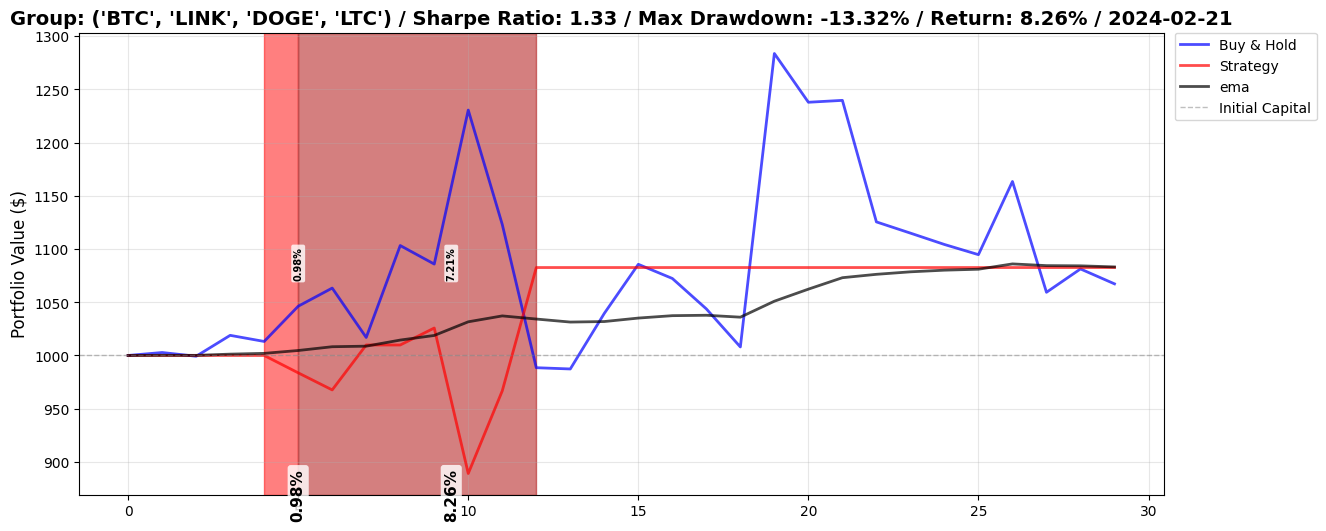

   Close  Open  Return  High   Low
0  21.83 22.12     NaN 24.16 19.98
1  20.93 21.83   -4.14 23.85 17.62
2  20.52 20.93   -1.98 23.33 17.31
3  20.70 20.52    0.88 23.61 17.72
4  21.51 20.70    3.94 23.28 18.40


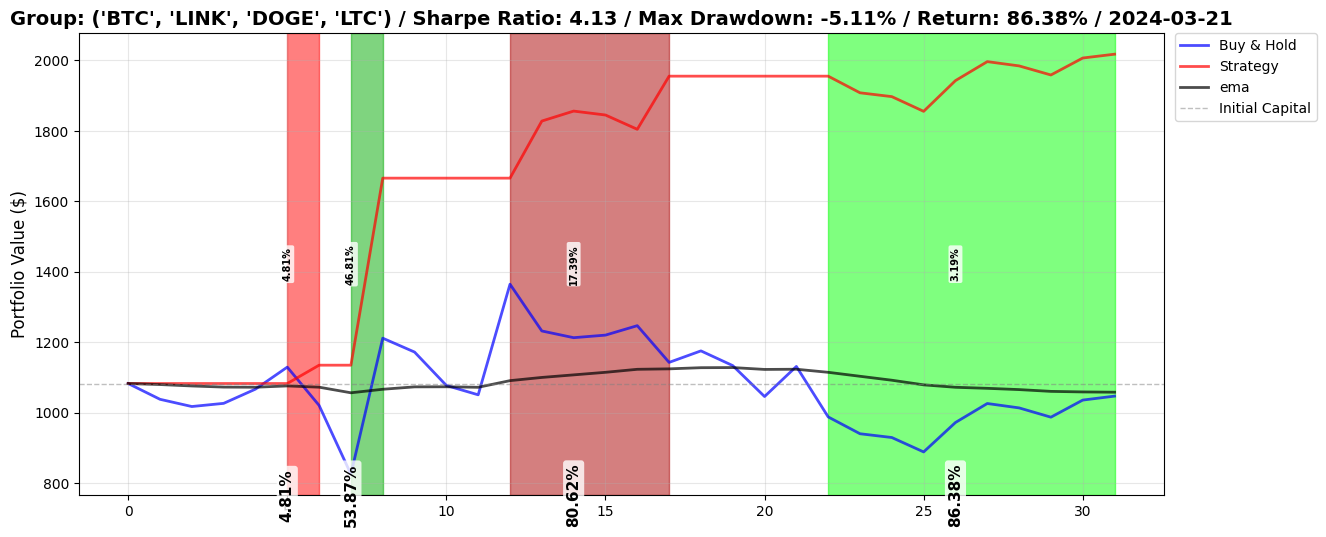

   Close  Open  Return  High   Low
0  18.35 18.03     NaN 19.80 16.37
1  18.82 18.35    2.52 20.30 16.95
2  18.75 18.82   -0.33 20.12 17.51
3  18.92 18.75    0.86 21.88 15.85
4  19.15 18.92    1.22 20.69 17.25


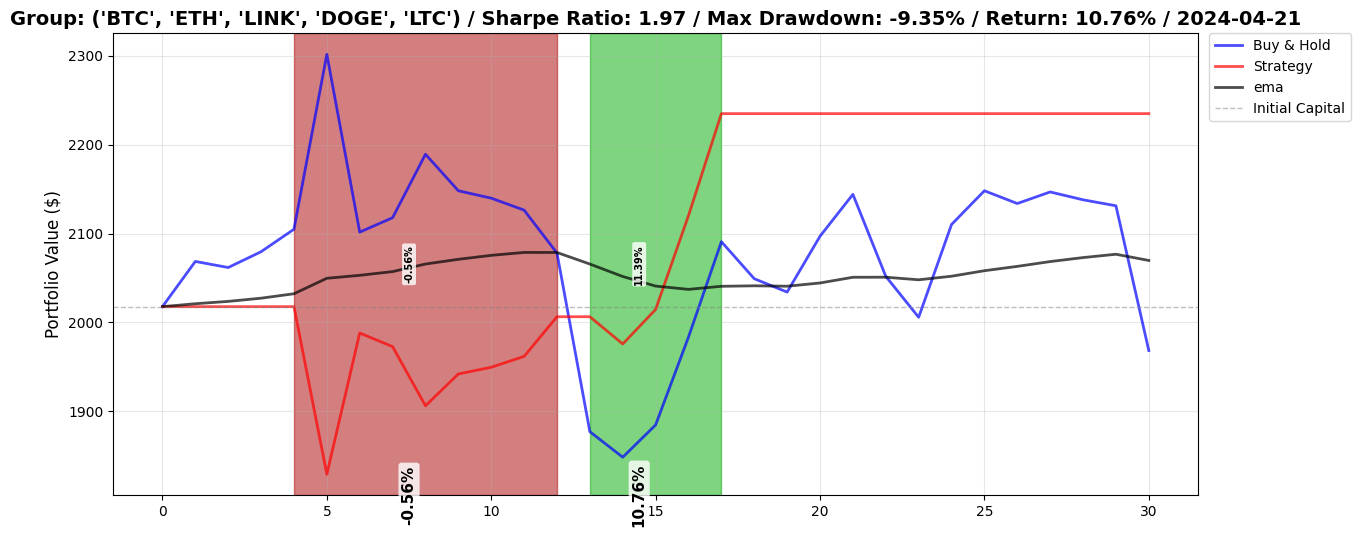

   Close  Open  Return  High   Low
0  16.25 16.37     NaN 17.98 14.81
1  15.79 16.25   -2.81 17.52 14.15
2  16.39 15.79    3.77 18.86 13.43
3  15.40 16.39   -6.04 17.38 13.58
4  14.26 15.40   -7.41 16.12 13.93


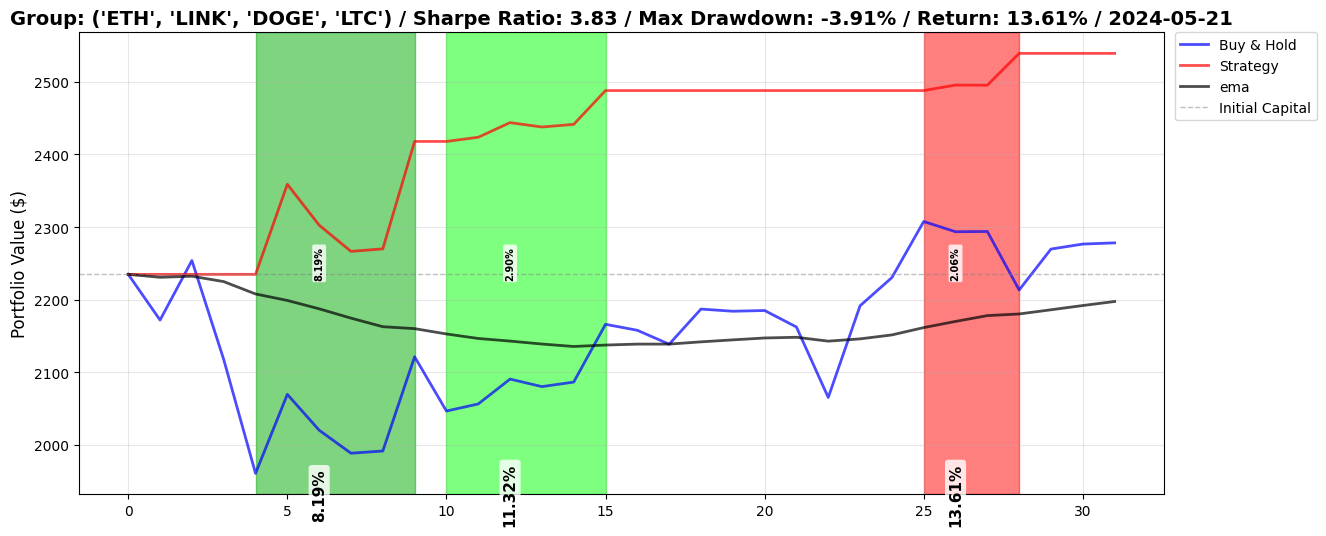

   Close  Open  Return  High   Low
0  18.62 18.77     NaN 19.34 17.35
1  18.95 18.62    1.75 19.22 18.17
2  18.59 18.95   -1.89 19.56 17.91
3  17.05 18.59   -8.29 19.80 15.38
4  16.82 17.05   -1.34 18.28 15.54


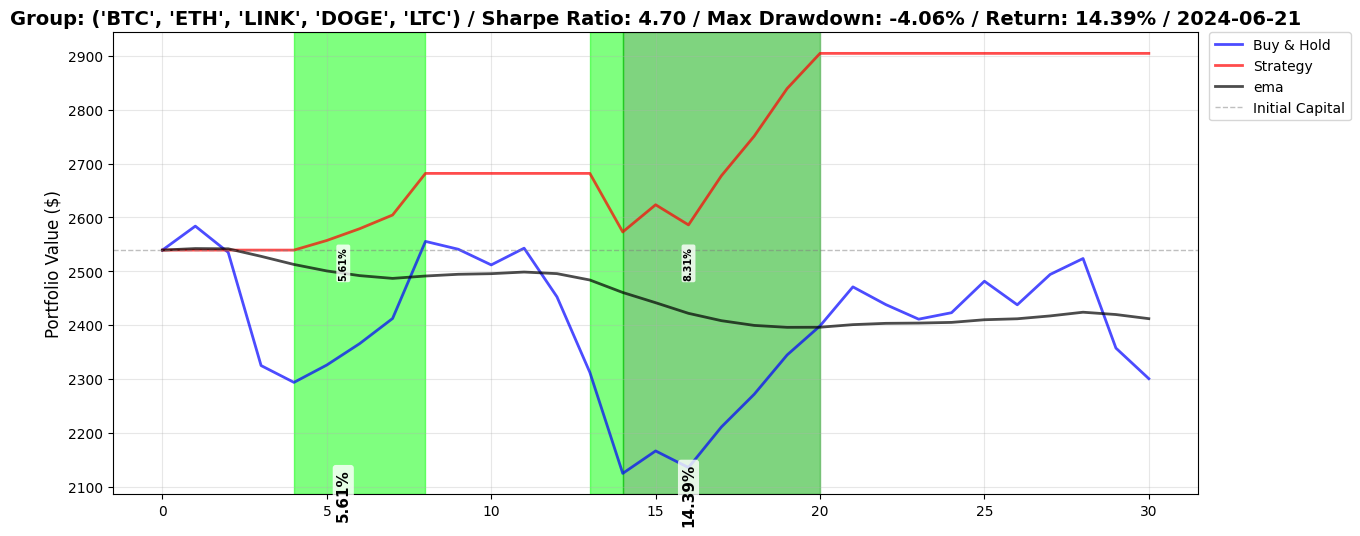

   Close  Open  Return  High   Low
0  11.88 12.63     NaN 15.13  9.64
1  16.20 11.88   36.36 18.44 10.39
2  13.56 16.20  -16.27 18.30 11.20
3  12.80 13.56   -5.61 16.98 10.49
4  12.16 12.80   -5.00 14.18 10.40


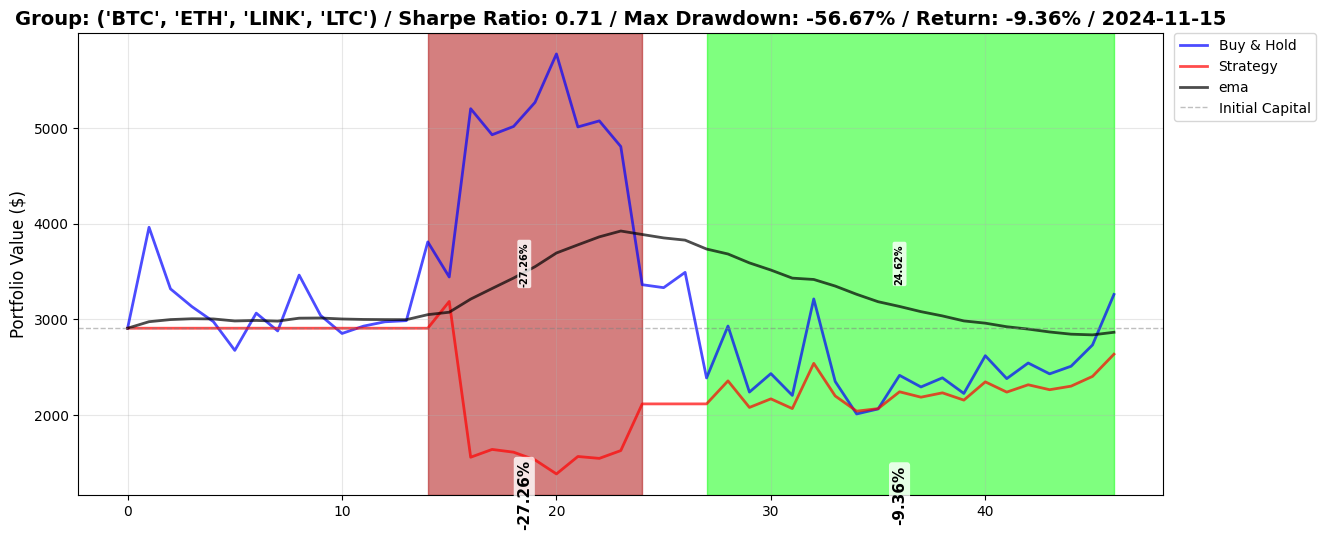

   Close  Open  Return  High   Low
0  19.79 19.21     NaN 21.84 17.27
1  19.87 19.79    0.41 21.52 18.31
2  19.59 19.87   -1.40 20.54 18.46
3  19.78 19.59    0.96 20.79 18.74
4  19.52 19.78   -1.31 22.80 16.11


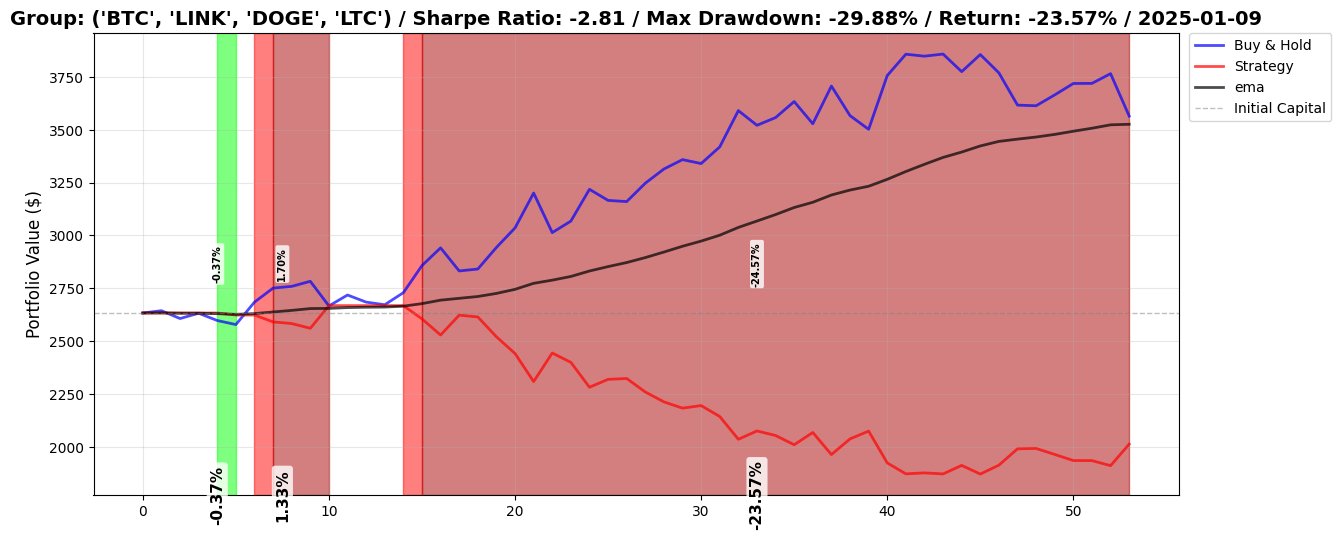

   Close  Open  Return  High   Low
0  22.61 24.10     NaN 27.89 18.43
1  22.84 22.61    1.01 25.37 19.55
2  23.12 22.84    1.25 24.85 21.15
3  22.42 23.12   -3.02 24.57 20.53
4  21.89 22.42   -2.36 24.43 19.69


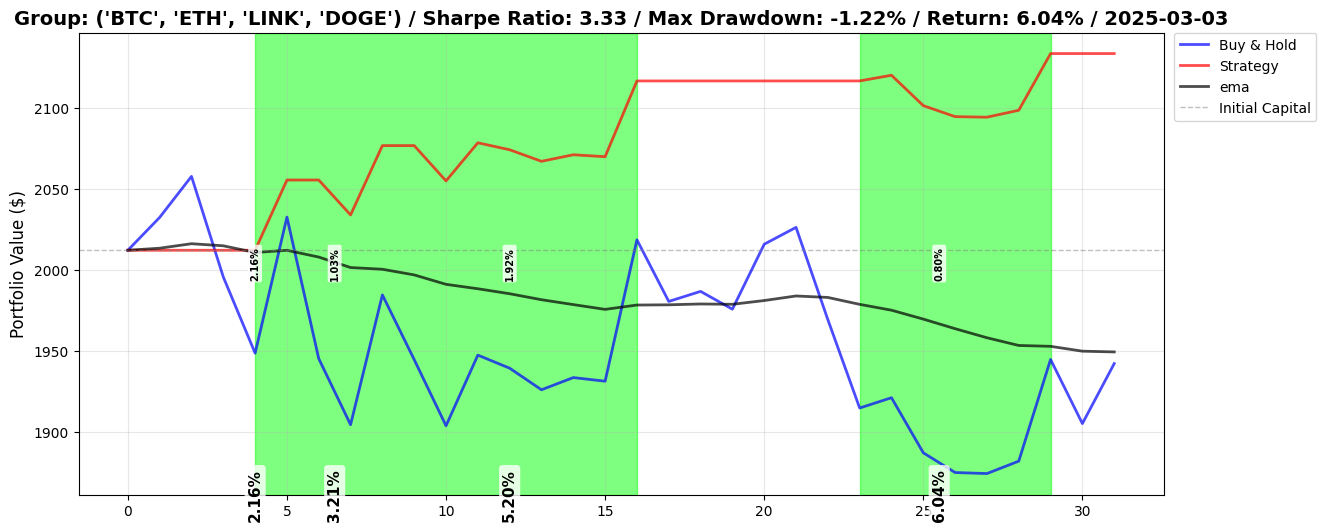

   Close  Open  Return  High   Low
0  21.66 21.26     NaN 22.64 20.28
1  21.49 21.66   -0.75 22.62 20.29
2  21.47 21.49   -0.12 22.08 20.68
3  20.33 21.47   -5.30 23.54 17.97
4  20.29 20.33   -0.17 22.86 17.74


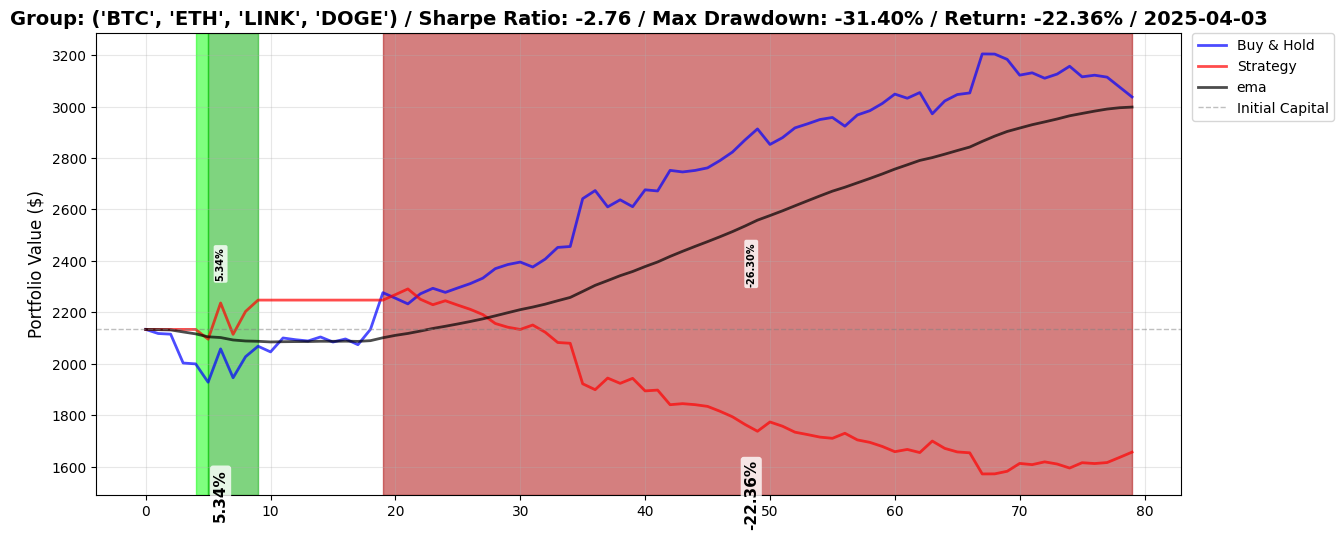

   Close  Open  Return  High   Low
0  11.24 11.29     NaN 12.20 10.32
1  11.05 11.24   -1.69 12.17  9.89
2  11.68 11.05    5.69 12.69  9.94
3  12.07 11.68    3.32 12.56 11.34
4  12.08 12.07    0.15 12.56 11.64


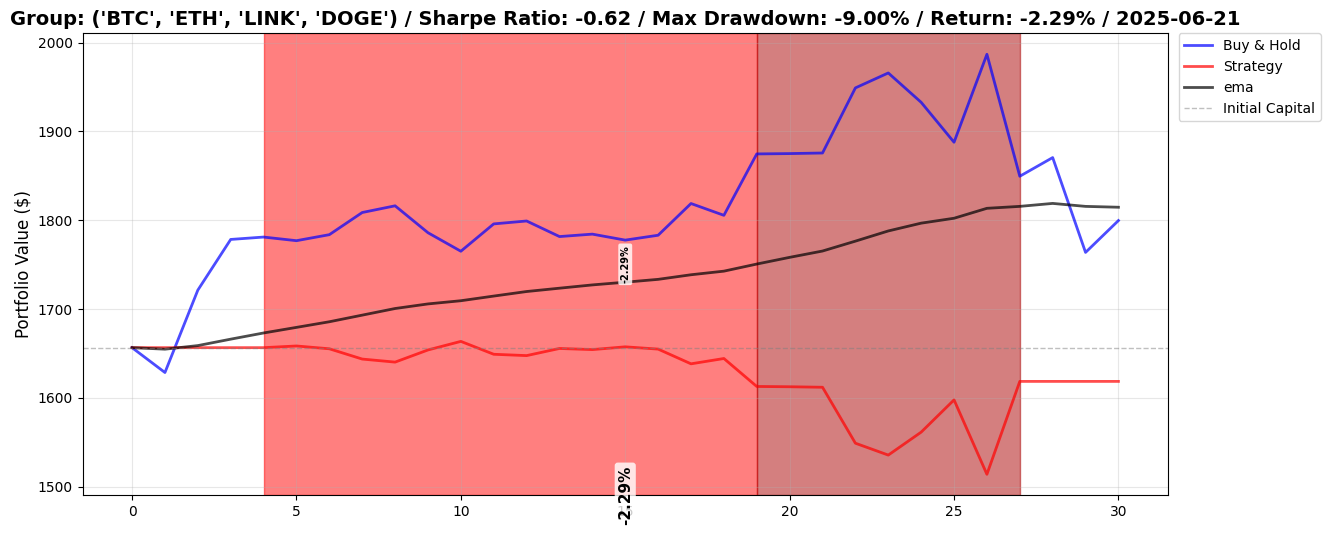

   Close  Open  Return  High   Low
0  13.71 14.22     NaN 14.90 13.01
1  13.56 13.71   -1.13 14.46 12.90
2  13.41 13.56   -1.11 14.14 12.53
3  13.08 13.41   -2.43 14.30 12.36
4  12.96 13.08   -0.92 14.10 11.86


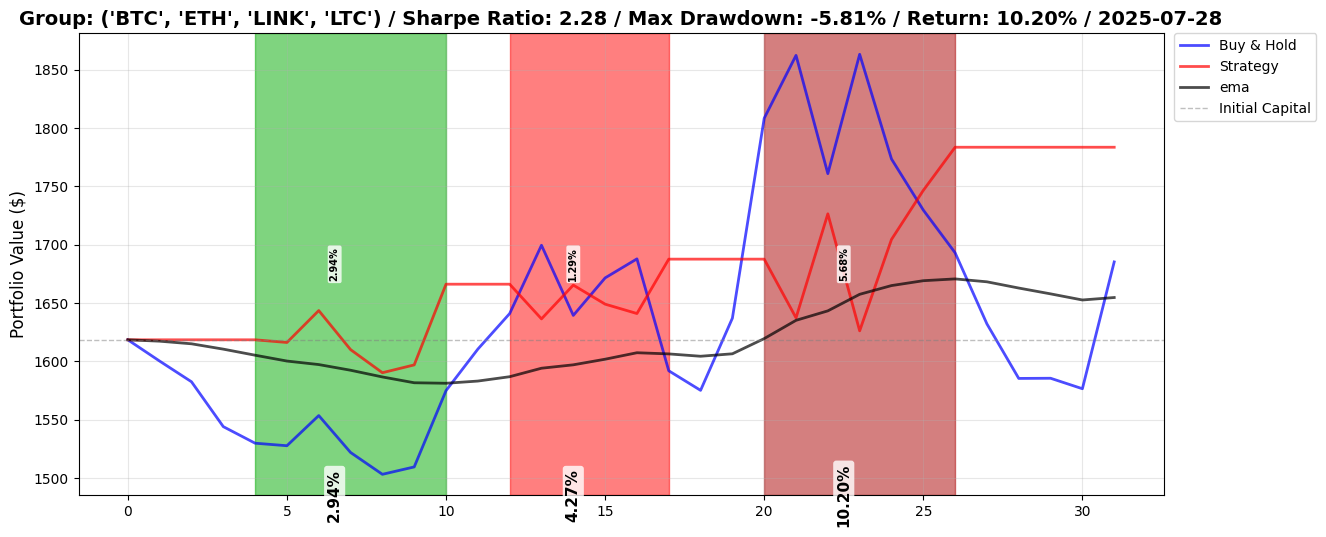

In [1140]:
mean_reversion_monthly_results = []
starting_date = datetime(2024, 1, 1)
current_budget = 1000
while starting_date < datetime(2025, 12, 20):
    res, new_start = no_bias_mean_reversion_bot(current_budget, starting_date.strftime('%Y-%m-%d'))
    starting_date = pd.to_datetime(new_start)
    try:
        current_budget = res['spread_df']['portfolio'].iloc[-1]
        res['sharpe'] = sharpe_ratio(res['spread_df']['strategy_return'])
        res['max_drawdown'] = max_drawdown(res['spread_df']['portfolio'])
        mean_reversion_monthly_results.append(res)
    except:
        continue
    
final_df = pd.concat([mean_reversion_monthly_results[i]['spread_df'] for i in range(len(mean_reversion_monthly_results))], ignore_index=True)

In [1141]:
Returns = list(map(lambda x: (x['spread_df']['portfolio'].iloc[-1] / x['spread_df']['portfolio'].iloc[0]) * 100 - 100, mean_reversion_monthly_results))
Portfolio = list(map(lambda x:  x['spread_df']['portfolio'].iloc[-1], mean_reversion_monthly_results))
start_dates = list(map(lambda x: (x['spread_df']['Date'].iloc[0]), mean_reversion_monthly_results))
end_dates = list(map(lambda x: (x['spread_df']['Date'].iloc[-1]), mean_reversion_monthly_results))

for i in range(len(Returns)):
    print(f"{Returns[i]:>5.2f}% in [{start_dates[i].date()} -> {end_dates[i].date()}] / Total: {(Portfolio[i] / 1000) * 100 - 100:>6.2f}%")

print(f"\nFinal portfolio value: {current_budget:.2f}$")
print(f"\nFinal Sharpe Ratio: {sharpe_ratio(final_df['strategy_return']):.2f}")
print(f"\nFinal Max Drawdown: {max_drawdown(final_df['portfolio']):.2f}%")
print(f"\nFinal Return: {(final_df['portfolio'].iloc[-1] / INITIAL_ASSET - 1) * 100:.2f}%")

 8.26% in [2024-02-21 -> 2024-03-21] / Total:   8.26%
86.38% in [2024-03-21 -> 2024-04-21] / Total: 101.78%
10.76% in [2024-04-21 -> 2024-05-21] / Total: 123.49%
13.61% in [2024-05-21 -> 2024-06-21] / Total: 153.92%
14.39% in [2024-06-21 -> 2024-07-21] / Total: 190.45%
-9.36% in [2024-11-15 -> 2024-12-31] / Total: 163.28%
-23.57% in [2025-01-09 -> 2025-03-03] / Total: 101.22%
 6.04% in [2025-03-03 -> 2025-04-03] / Total: 113.37%
-22.36% in [2025-04-03 -> 2025-06-21] / Total:  65.65%
-2.29% in [2025-06-21 -> 2025-07-21] / Total:  61.85%
10.20% in [2025-07-28 -> 2025-08-28] / Total:  78.36%

Final portfolio value: 1783.56$

Final Sharpe Ratio: 0.80

Final Max Drawdown: -56.67%

Final Return: 78.36%


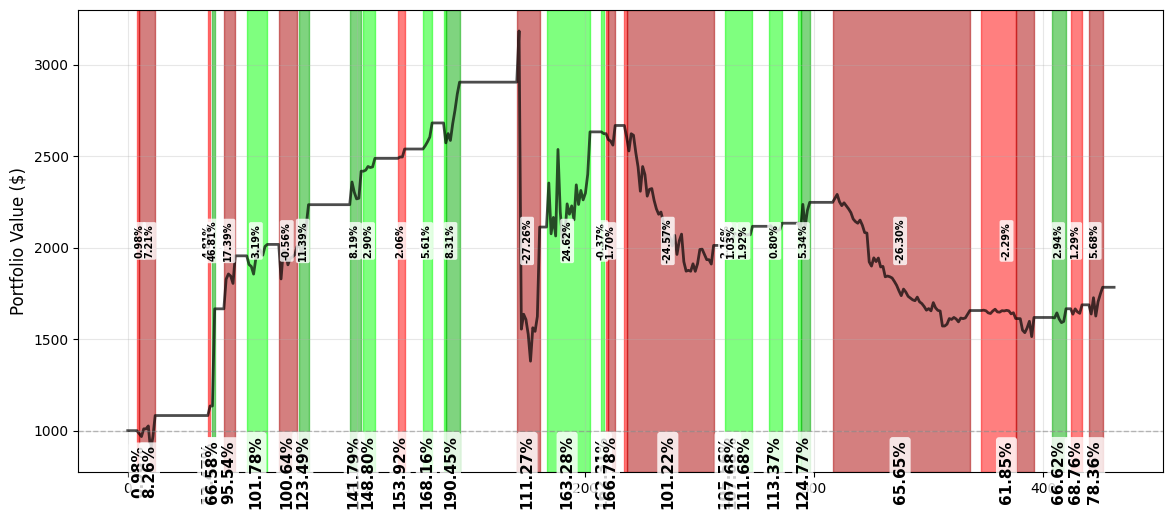

In [1142]:
df = final_df
plt.figure(figsize=(14, 6))

plt.plot(df.index, df['portfolio'], label='equity', linewidth=2, alpha=0.7, color='black')

plt.axhline(y=INITIAL_ASSET, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.grid(True, alpha=0.3)

ax = plt.gca() # Get current axes
long1pos = (df['position'] == 1) | (df['position'].shift(1) == 1)
long2pos = (df['position'] == 2) | (df['position'].shift(1) == 2)
short1pos = (df['position'] == -1) | (df['position'].shift(1) == -1)
short2pos = (df['position'] == -2) | (df['position'].shift(1) == -2)
plt.fill_between(df.index, 0, 1, where=(long1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0F0')
plt.fill_between(df.index, 0, 1, where=(short1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#F00')
plt.fill_between(df.index, 0, 1, where=(long2pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0A0')
plt.fill_between(df.index, 0, 1, where=(short2pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#A00')

df['trade_id'] = (np.sign(df['position']) != np.sign(df['position'].shift())).cumsum()

active_df = df[df['position'] != 0].copy()

if not active_df.empty:
    temp_df = active_df.reset_index()
    idx_col = temp_df.columns[0]
    
    # 3. Aggregate metadata
    trades = temp_df.groupby('trade_id').agg(
        pos_type=('position', 'first'),
        start_idx=(idx_col, 'first'),
        end_idx=(idx_col, 'last')
    )

    running_total_gain = 1
    
    for t_id, trade in trades.iterrows():
        # --- LAG FIX ---
        start_val = df.loc[trade['start_idx'], 'portfolio']
        try:
            end_val = df.loc[trade['end_idx'] + 1, 'portfolio']
        except:
            end_val = df.loc[trade['end_idx'], 'portfolio']

        actual_trade_return = (end_val / start_val - 1) * 100
        
        # Calculate Running Total (Total Gain from $initial_asset start)
        running_total_gain = (end_val / INITIAL_ASSET - 1) * 100
        
        # Calculate horizontal center for the label
        mid_point = (trade['start_idx'] + trade['end_idx']) / 2
        
        label1 = f"{actual_trade_return:.2f}%"
        label2 = f"{running_total_gain:.2f}%"
        
        # 4. Placement
        ax.text(mid_point, 0.5, label1, 
                transform=ax.get_xaxis_transform(),
                fontweight='bold',
                ha='center', va='center', 
                fontsize=7, rotation=90,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
        
        ax.text(mid_point, 0, label2, 
                transform=ax.get_xaxis_transform(),
                fontweight='bold',
                ha='center', va='center', 
                fontsize=11, rotation=90,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
plt.show()

In [1143]:
mean_reversion_bot = final_df
mean_reversion_bot['percent_invested'] = np.abs(mean_reversion_bot['position']) * 50
mean_reversion_bot.head()

,Close,Open,Return,High,Low,std,ema,Date,coin,weights,position,strategy_return,portfolio,BNH,trade_id,percent_invested
0,29.12,29.11,NaN,30.27,27.47,NaN,29.12,2024-02-21,BTC*LINK*DOGE*LTC,0.00021825727800312217*-0.4015543793879231*-14...,0.00,0.00,1000.00,1000.00,1,0.00
1,29.20,29.12,0.28,30.06,28.08,NaN,29.12,2024-02-22,BTC*LINK*DOGE*LTC,0.00021825727800312217*-0.4015543793879231*-14...,0.00,0.00,1000.00,1002.78,1,0.00
2,29.10,29.20,-0.35,29.81,28.06,NaN,29.12,2024-02-23,BTC*LINK*DOGE*LTC,0.00021825727800312217*-0.4015543793879231*-14...,0.00,-0.00,1000.00,999.27,1,0.00
3,29.67,29.10,1.97,30.48,28.45,NaN,29.16,2024-02-24,BTC*LINK*DOGE*LTC,0.00021825727800312217*-0.4015543793879231*-14...,0.00,0.00,1000.00,1018.91,1,0.00
4,29.50,29.67,-0.56,30.06,29.03,0.25,29.18,2024-02-25,BTC*LINK*DOGE*LTC,0.00021825727800312217*-0.4015543793879231*-14...,-1.00,-0.00,1000.00,1013.17,2,50.00


# Martingale Bot

In [1144]:
def atr(
    df: pd.DataFrame, 
    period: int = 14
):
    high = df["High"]
    low = df["Low"]
    close = df["Close"]

    tr1 = high - low
    tr2 = (high - close.shift()).abs()
    tr3 = (low - close.shift()).abs()

    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return tr.rolling(period).mean()

In [1145]:
def above_ema200(df: pd.DataFrame, percentage: float = 70.0):
    ema200 = df['Close'].ewm(span=200, adjust=False).mean()
    above_ema = df['Close'] > ema200
    above_percentage = above_ema.mean() * 100
    return above_percentage > percentage

In [1146]:
def strong_trend_range(
    df: pd.DataFrame, 
    atr_lookback: int = 14, 
    atr_period: int = 30
) -> bool:
    atr_df = atr(df, atr_lookback)
    recent_atr = atr_df.mean()
    average_price = df["Close"].mean()
    
    return (recent_atr / average_price) > 8 / 100

In [1147]:
def grid_spacing(
    df: pd.DataFrame, 
    atr_period: int = 14, 
    multiplier: float = 1.0
) -> pd.Series: # in percent
    atr_df = atr(df, atr_period)
    return (atr_df * multiplier) / df['Close']

In [1148]:
top_tickers = []
tickers = TOP_50 if MR_MODE == "explore" else SELECTED_TICKERS
for ticker in tickers:
    starting_train_date = (datetime(2025, 1, 1) - relativedelta(month=6)).strftime('%Y-%m-%d')
    # df = filter_ticker(ticker=ticker, start="2024-07-01", end="2025-01-01")
    df = fetch_data(ticker=ticker, start="2023-07-01", end="2025-01-01")
    
    if df.empty:
        continue
    
    mode = []
    if above_ema200(df):
        # print(f"{ticker:<6} was above EMA200 with {above_ema200(df)}")
        mode.append("trend")
        pass
        
    if strong_trend_range(df):
        # print(f"{ticker:<6} did have a strong trend or range")
        mode.append("range")
        
    if len(mode) >= 0:
        # df = filter_ticker(ticker=ticker, start=START_DATE, end=END_DATE)
        df = fetch_data(ticker=ticker, start=START_DATE, end=END_DATE)
        df['ATR'] = grid_spacing(df, atr_period=14, multiplier=1.0).fillna(0)
        df['Return'] = df['Close'].pct_change(fill_method=None) * 100
        if PLOT_RESULT:
            store_series_plot(df, ticker)

        top_tickers.append({
            "df": df,
            "symbol": ticker,
            "mode": mode,
        })

In [1149]:
print(f"{len(top_tickers)} results were found")
top_tickers.sort(key=lambda ticker: ticker['df']['ATR'].median() , reverse=True)
print("\n".join(list(map(lambda ticker: f"{ticker['symbol']:>5}: {ticker['df']['ATR'].median() * 100:>5.2f}, {str(ticker['mode']):>5}", top_tickers))))

5 results were found
 DOGE:  7.18, ['range']
 LINK:  6.55,    []
  LTC:  5.30,    []
  ETH:  4.99,    []
  BTC:  3.52, ['trend']


In [1150]:
top_tickers

[{'df':           Date  Open  High  Low  Close        Volume  ATR  Return
  0   2024-01-01  0.09  0.09 0.09   0.09  908498410.58 0.00     NaN
  1   2024-01-02  0.09  0.09 0.09   0.09 1649263525.15 0.00   -1.00
  2   2024-01-03  0.09  0.09 0.08   0.08 3972288031.93 0.00   -9.98
  3   2024-01-04  0.08  0.08 0.08   0.08 2002599795.79 0.00    2.44
  4   2024-01-05  0.08  0.08 0.08   0.08 2224965816.36 0.00   -1.58
  ..         ...   ...   ...  ...    ...           ...  ...     ...
  602 2025-08-25  0.23  0.23 0.21   0.21 4039196029.58 0.09   -9.53
  603 2025-08-26  0.21  0.22 0.21   0.22 2341129136.77 0.08    4.15
  604 2025-08-27  0.22  0.22 0.22   0.22 2463489774.98 0.08    0.23
  605 2025-08-28  0.22  0.23 0.22   0.22 2037640819.28 0.07    2.51
  606 2025-08-29  0.22  0.23 0.22   0.22   92866412.10 0.07   -0.58
  
  [607 rows x 8 columns],
  'symbol': 'DOGE',
  'mode': ['range']},
 {'df':           Date  Open  High   Low  Close      Volume  ATR  Return
  0   2024-01-01 14.94 15.58 14.81

In [1151]:
def grid_levels(
    base_price: float,
    step_percent: float = 3 / 100, 
    levels: int = MAX_LEVELS,
    mode: Literal['normal', 'anti'] = 'normal'
) -> np.ndarray:
    if mode == 'normal':
        return base_price * (1 - step_percent) ** np.arange(levels + 1)
    else:
        return base_price * (1 + step_percent) ** np.arange(-1, levels + 1)

In [1152]:
def martingale_sizing(
    base_volume: float, 
    levels: int = MAX_LEVELS, 
    multiplier: float = MARTINGALE_K
) -> np.ndarray:
    return base_volume * (multiplier ** np.arange(levels))

In [1153]:
def average_price(
    base_price,
    base_volume,
    current_level,
    step_percent,
    mode: Literal['normal', 'anti'] = 'normal'
) -> float:
    prices = grid_levels(base_price, step_percent, current_level - 1, mode)[:-1]
    if mode == 'anti':
        prices = prices[1:]
    volumes = martingale_sizing(base_volume, current_level - 1)

    prices = np.array(prices, dtype=float)
    volumes = np.array(volumes, dtype=float)

    total_cost = np.sum(prices * volumes)
    total_size = np.sum(volumes)
    return float(total_cost / total_size) if total_size > 0 else base_price

In [1154]:
def calculate_base_volume(
    base_price: float,
    asset: float = INITIAL_ASSET, 
    max_levels: int = MAX_LEVELS, 
    multiplier: float = MARTINGALE_K
) -> float:
    total_factor = (multiplier ** max_levels - 1) / (multiplier - 1)

    base_asset = asset / total_factor
    base_volume = base_asset / base_price

    return base_volume

In [1155]:
def calculate_new_investment(
    remaining: float,
    current_level: int,
    max_levels: int = MAX_LEVELS, 
    multiplier: float = MARTINGALE_K
) -> float:
    levels_left = max_levels - current_level + 1
    return remaining * (multiplier - 1) / (multiplier**levels_left - 1)

In [1165]:
def martingale_strategy(ticker):
    # for ticker in top_tickers[i:i+1]:
    # ticker = top_tickers[0]
    # ticker = top_tickers[3]
    if "range" not in ticker["mode"]:
        print(f"{ticker['symbol']} isn't a range ticker")
        # continue
    print(ticker['symbol'])
    trades = []

    df = ticker['df']

    current_level = 0
    start_trade = 0

    strategy_return = []
    invested_asset = []
    levels = []
    remaining = []
    volume_asset = []
    exit_prices = []


    volume_filled = 0
    remaining_asset = INITIAL_ASSET

    terminated = False
    for time, row in df.iterrows():
        if row['ATR'] == 0 or terminated:
            levels.append(0)
            invested_asset.append(0)
            strategy_return.append(0)
            volume_asset.append(0)
            exit_prices.append(0)
            remaining.append(remaining_asset)
            continue
        
        price_high = row["Close" if ANCHOR == "Body" else "High"]
        price_low  = row["Close" if ANCHOR == "Body" else "Low"]
        
        if current_level == 0:
            start_trade = time
            current_level = 1
            new_investment = calculate_new_investment(remaining_asset, current_level)
            remaining_asset -= new_investment
            volume_filled += new_investment / df.iloc[start_trade]["Open"]
        
        step = df['ATR'].iloc[start_trade]
        base_price = df.iloc[start_trade]["Open"]
        base_volume = calculate_base_volume(base_price)
        
        grid_prices = grid_levels(base_price, step, MAX_LEVELS, 'normal')

        # ---- Safety Grids ----
        while (current_level < MAX_LEVELS and price_low < grid_prices[current_level - 1]):
            # print(f"Next level in {time} cause {price} < {grid_prices[current_level - 1]}")
            current_level += 1
            new_investment = calculate_new_investment(remaining_asset, current_level)
            remaining_asset -= new_investment
            volume_filled += new_investment / grid_prices[current_level - 1]

        avg_price = average_price(base_price, base_volume, current_level, df['ATR'].iloc[start_trade])
        
        # ---- Take Profit ----
        ROUND = 30
        
        filled_volumes = martingale_sizing(base_volume, current_level - 1)
        total_volume = sum(filled_volumes)

        reached_target_profit = (avg_price > 0 and price_high >= avg_price * (1 + TP_PERCENT)) or (avg_price == 0 and price_high >= base_price * (1 + TP_PERCENT))
        
        filled_all_levels = (price_low < grid_prices[-1])

        exit_price = max(float(avg_price * (1 + TP_PERCENT)), float(df['Low'].iloc[time]))
        pnl_usd = float((exit_price - avg_price) * total_volume)
        pnl_pct = float((pnl_usd / INITIAL_ASSET) * 100)

        end_price = exit_price if reached_target_profit else grid_prices[-1] if filled_all_levels else df['Close'].iloc[time]
        total_invested = end_price * volume_filled
        invested_asset.append(total_invested)
        levels.append(current_level)
        remaining.append(remaining_asset)
        volume_asset.append(volume_filled)
        exit_prices.append(exit_price)
        # ---- Take Profit ----
        if reached_target_profit:
            trades.append({
                "trade_open": start_trade,
                "trade_close": time,
                "open_price": round(float(df["Open"].iloc[start_trade]), ROUND),
                "exit_price": round(exit_price, ROUND),
                "avg_price": round(avg_price, ROUND),
                "pnl_usd": round(pnl_usd, 4),
                "pnl_pct": round(pnl_pct, 4),
                "spacing": round(float(df['ATR'].iloc[start_trade]), ROUND),
                "levels_filled": current_level - 1,
                "exit_type": "TP"
            })
            remaining_asset += volume_filled * exit_price
            volume_filled = 0
            current_level = 0
            continue

        # ---- Stop Loss (price below last grid) ----
        if filled_all_levels:
            trades.append({
                "trade_open": start_trade,
                "trade_close": time,
                "open_price": float(df["Open"].iloc[start_trade]),
                "exit_price": round(float(grid_prices[-1]), ROUND),
                "avg_price": round(avg_price, ROUND),
                "pnl_usd": round(pnl_usd, 4),
                "pnl_pct": round(pnl_pct, 4),
                "spacing": round(float(df['ATR'].iloc[start_trade]), ROUND),
                "levels_filled": current_level + 1,
                "exit_type": "SL"
            })
            remaining_asset += volume_filled * grid_prices[-1]
            volume_filled = 0
            terminated = True
        

    base_price = df.iloc[start_trade]["Open"]
    base_volume = calculate_base_volume(base_price)
    avg_price = average_price(base_price, base_volume, current_level - 1, df['ATR'].iloc[start_trade])

    filled_volumes = martingale_sizing(base_volume, current_level)
    total_volume = sum(filled_volumes)
    ROUND = 30

    pnl_usd = float((df["Close"].iloc[-1] - avg_price) * total_volume)
    pnl_pct = float((pnl_usd / INITIAL_ASSET) * 100)

    if current_level > 0 and len(trades) > 0 and trades[-1]['exit_type'] != "SL":
        trades.append({
            "trade_open": start_trade,
            "trade_close": len(df) - 1,
            "open_price": df.iloc[start_trade]["Open"],
            "exit_price": df["Close"].iloc[-1],
            "avg_price": round(avg_price, ROUND),
            "pnl_usd": round(pnl_usd, ROUND),
            "pnl_pct": round(pnl_pct, ROUND),
            "spacing": df['ATR'].iloc[start_trade],
            "levels_filled": current_level,
            "exit_type": "SL" if (df["Close"].iloc[-1] < avg_price) else "TP"
        })
        
    df['remaining'] = remaining
    df['invested'] = invested_asset
    df['portfolio'] = df['remaining'] + df['invested']
    df['percent_invested'] = df['invested'] / df['portfolio']
    df['strategy_return'] = df['portfolio'].pct_change(fill_method=None) * 100
    df['volume_asset'] = volume_asset
    df['level'] = levels
    df['exit_price'] = exit_prices
    df['coin'] = ticker['symbol']
    report_martingale(df, trades)
    # plot_portfolio(df)
    plot_trades(
        df=df,
        trades=trades,
        ticker=ticker['symbol']
    )
    df = df.fillna(0)
    return df
# df.tail(100)
        
martingale_dfs = {ticker['symbol']: martingale_strategy(ticker) for ticker in top_tickers}

DOGE
Total result:
Max Drawdown:    -21.66%
Sharpe Ratio:    -0.276
Sortino Ratio:   -0.205
Strategy Return: -4.781%
Time Underwater: 265
Profit Factor:   1.65
Grid Efficiency: 52.00


LINK isn't a range ticker
LINK
Total result:
Max Drawdown:    -5.69%
Sharpe Ratio:    +0.765
Sortino Ratio:   +0.913
Strategy Return: +36.101%
Time Underwater: 258
Profit Factor:   54.22
Grid Efficiency: 78.00


LTC isn't a range ticker
LTC
Total result:
Max Drawdown:    -1.82%
Sharpe Ratio:    +0.375
Sortino Ratio:   +0.588
Strategy Return: +14.329%
Time Underwater: 225
Profit Factor:   17.88
Grid Efficiency: 58.00


ETH isn't a range ticker
ETH
Total result:
Max Drawdown:    -2.42%
Sharpe Ratio:    +0.312
Sortino Ratio:   +0.531
Strategy Return: +14.035%
Time Underwater: 516
Profit Factor:   29.43
Grid Efficiency: 68.00


BTC isn't a range ticker
BTC
Total result:
Max Drawdown:    -1.03%
Sharpe Ratio:    -1.048
Sortino Ratio:   -1.268
Strategy Return: +5.964%
Time Underwater: 117
Profit Factor:   4.61
Grid Efficiency: 56.00


# ADX Bot

In [1157]:
def apply_dm_logic(row):
    dmp = row['DMP']
    dmn = row['DMN']
    
    dm_plus = dmp if dmp > 0 else 0
    dm_minus = -dmn if dmn < 0 else 0 
    
    if dm_plus > 0 and dm_minus > 0:
        if dm_plus > dm_minus:
            dm_minus = 0
        else:
            dm_plus = 0
            
    return pd.Series({'DM_Plus': dm_plus, 'DM_Minus': dm_minus})

In [1158]:
def report_adx(df):
    print("Total result:")
    print(f"Max Drawdown:    {max_drawdown(df['portfolio']):.2f}%")
    print(f"Sharpe Ratio:    {sharpe_ratio(df['strategy_return']):+.3f}")
    print(f"Sortino Ratio:   {sortino_ratio(df['strategy_return']):+.3f}")
    print(f"Strategy Return: {((df['portfolio'].iloc[-1] / df['portfolio'].iloc[0]) - 1) * 100:+.3f}%")

Reporting BTC
Total result:
Max Drawdown:    -53.40%
Sharpe Ratio:    +0.283
Sortino Ratio:   +0.411
Strategy Return: +19.313%
Reporting ETH
Total result:
Max Drawdown:    -31.14%
Sharpe Ratio:    +1.319
Sortino Ratio:   +2.089
Strategy Return: +366.757%
Reporting LINK
Total result:
Max Drawdown:    -60.69%
Sharpe Ratio:    +0.405
Sortino Ratio:   +0.688
Strategy Return: +17.473%
Reporting DOGE
Total result:
Max Drawdown:    -93.88%
Sharpe Ratio:    -0.096
Sortino Ratio:   -0.136
Strategy Return: -60.448%
Reporting LTC
Total result:
Max Drawdown:    -78.06%
Sharpe Ratio:    -0.401
Sortino Ratio:   -0.549
Strategy Return: -63.542%


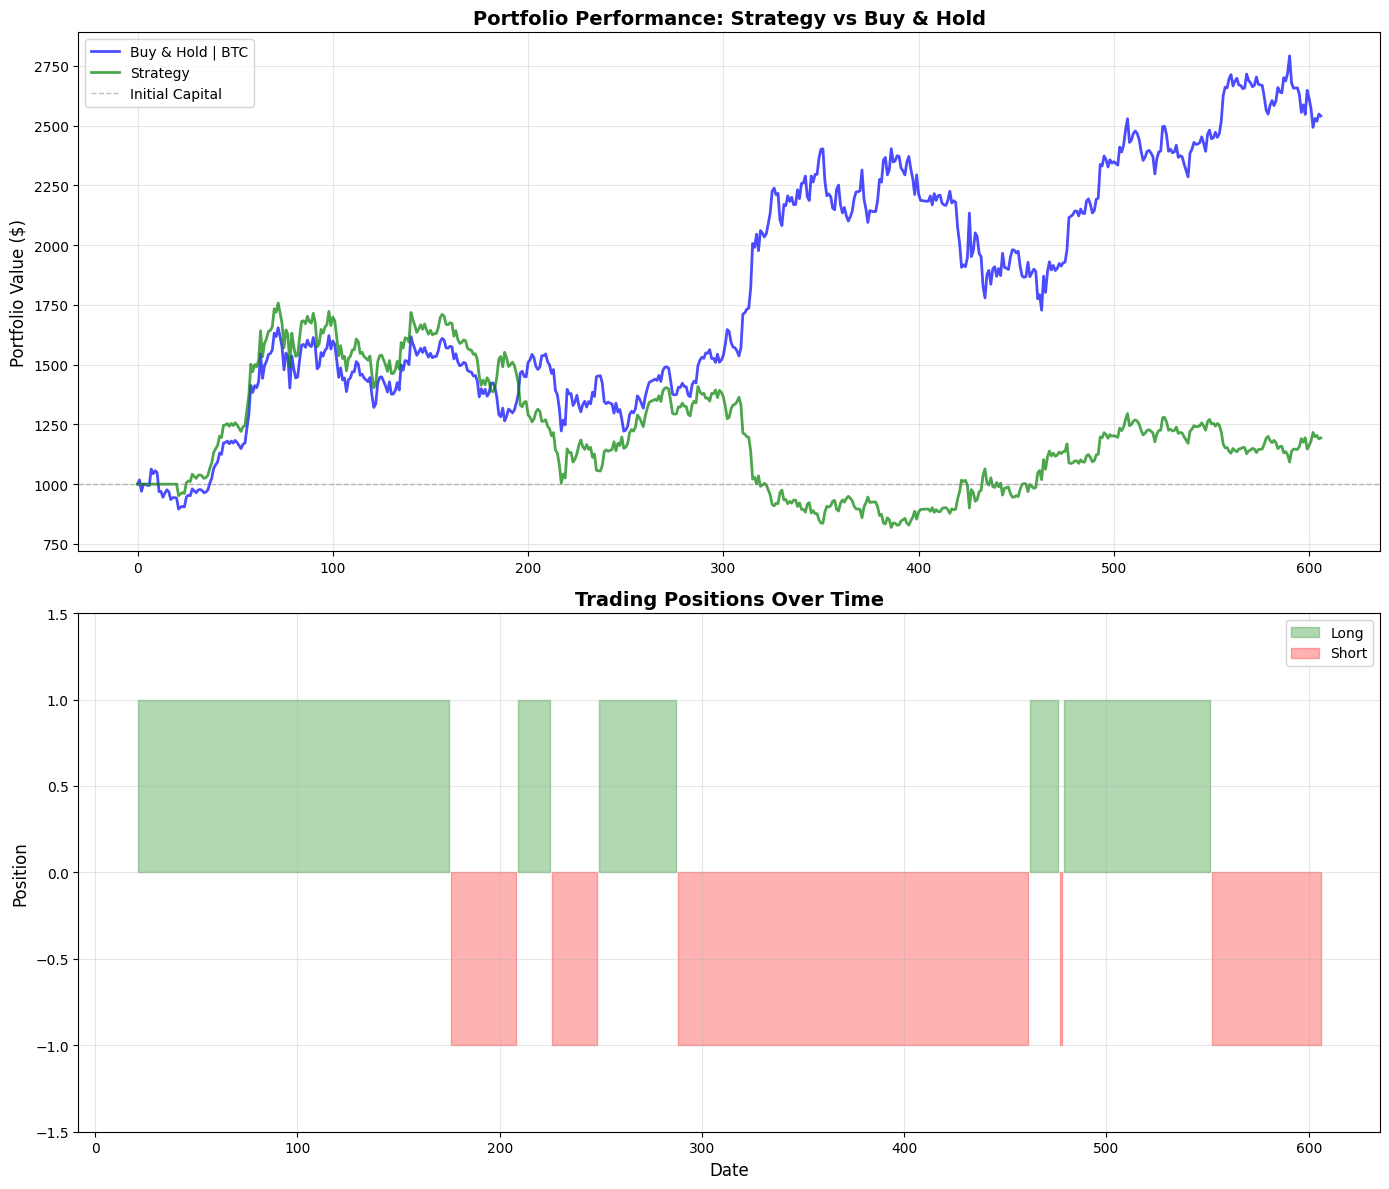

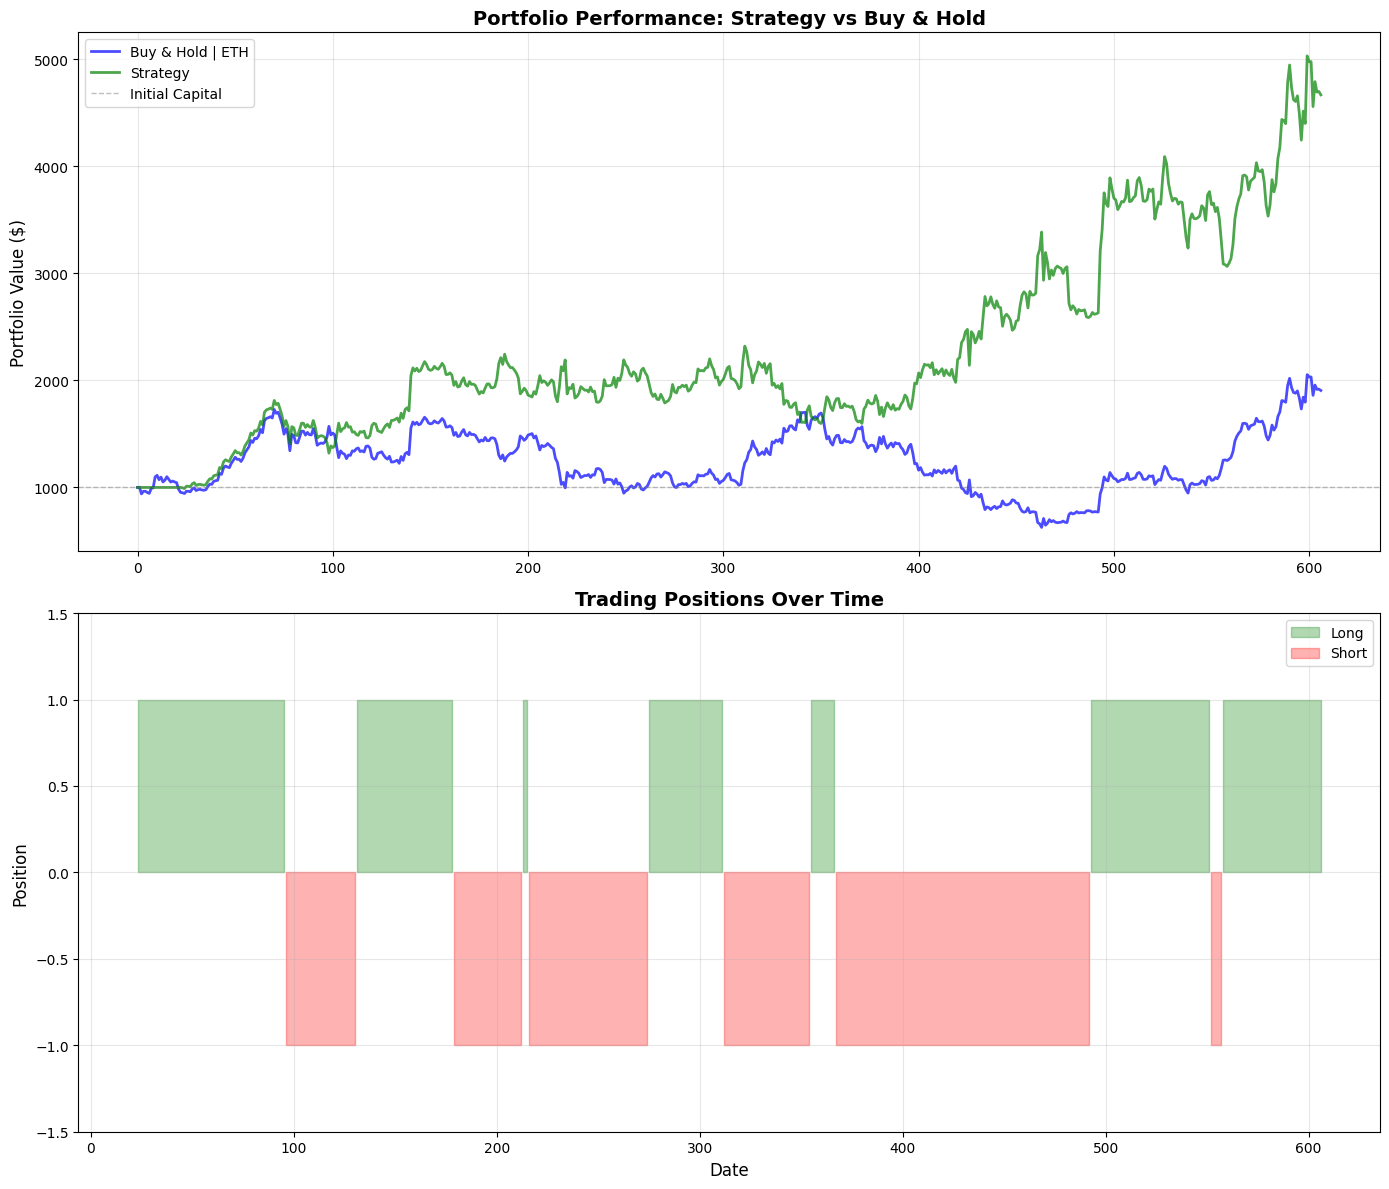

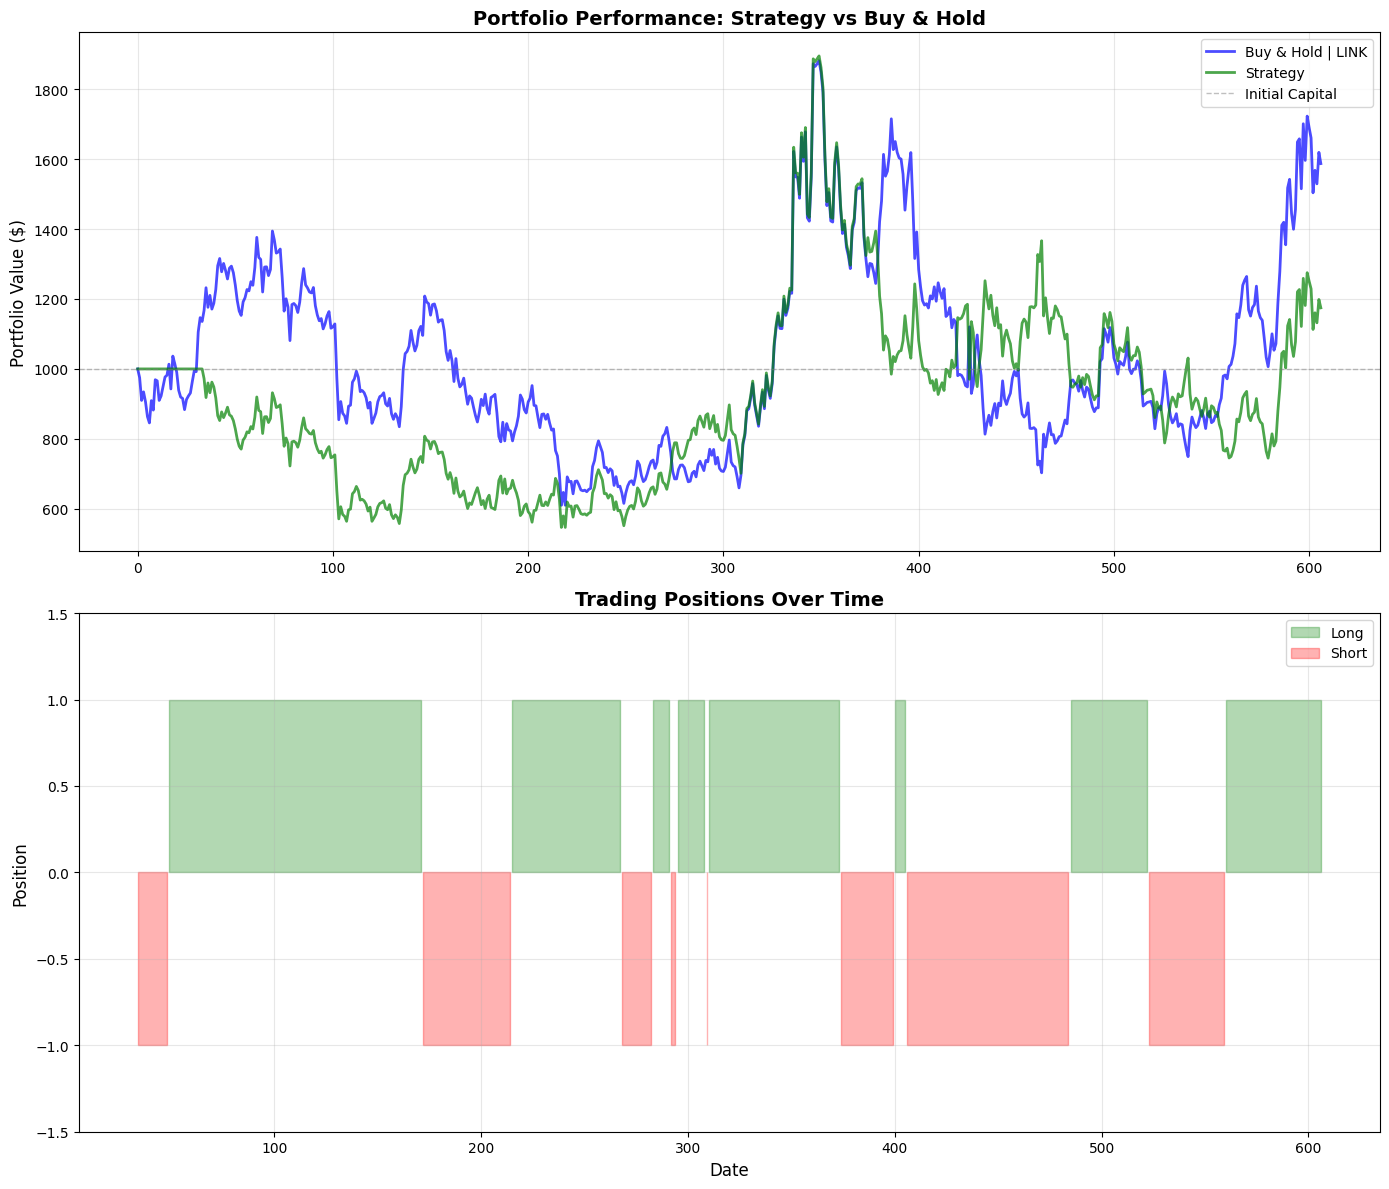

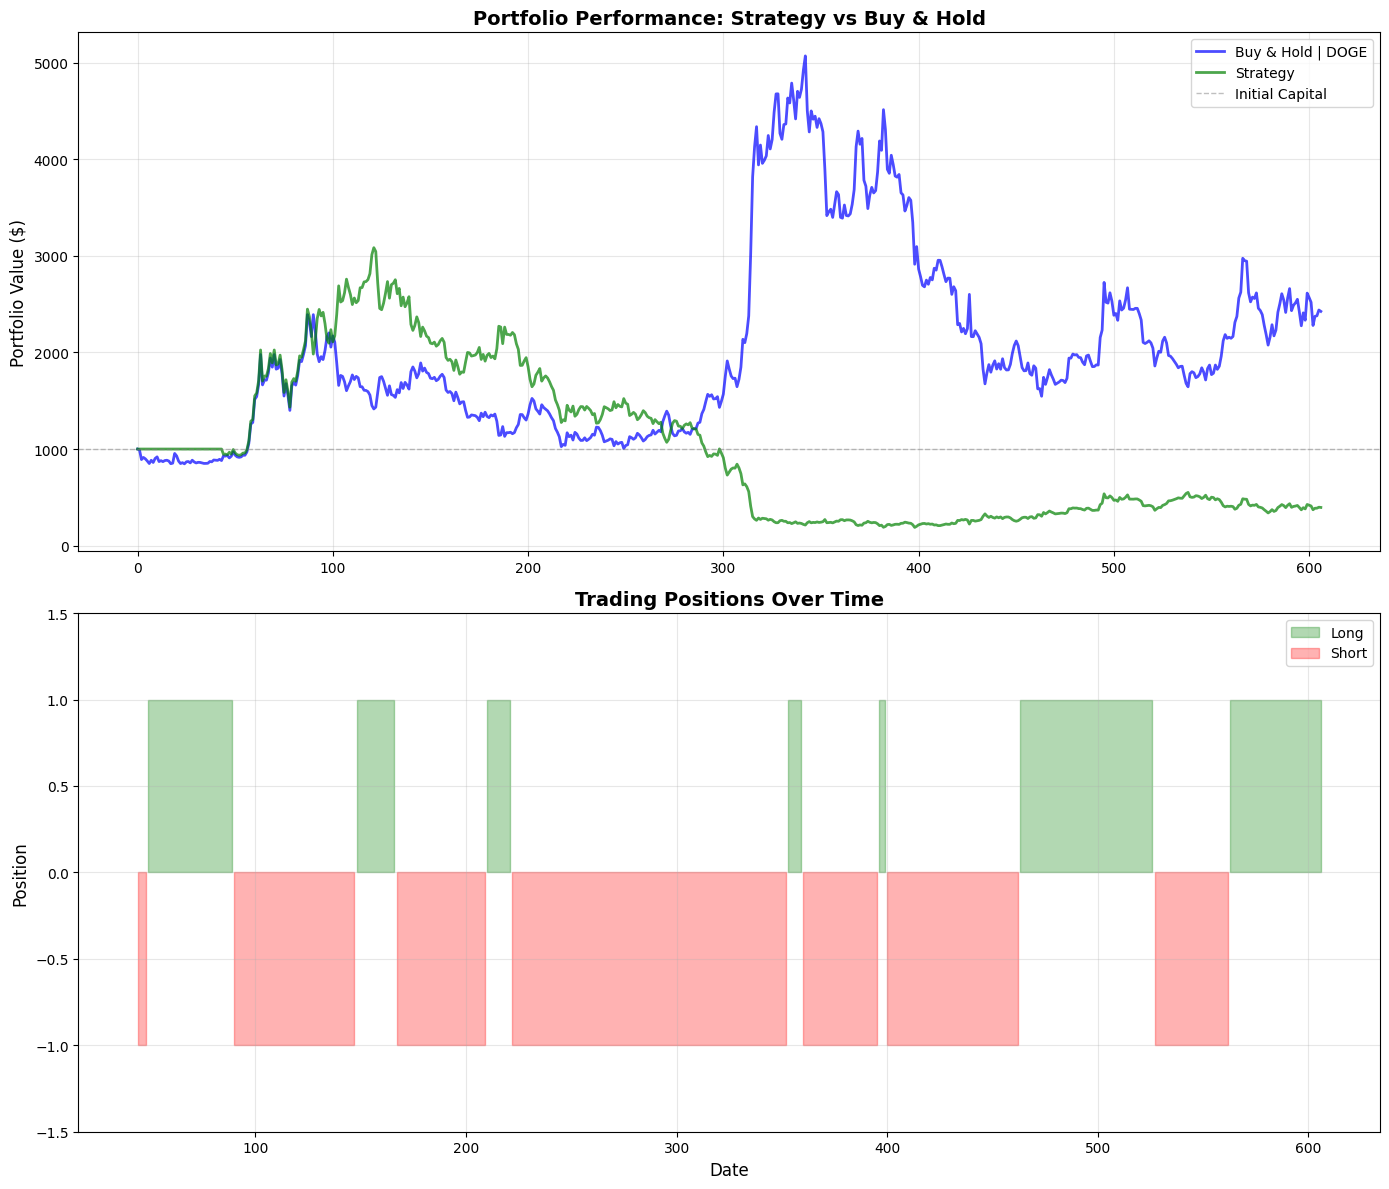

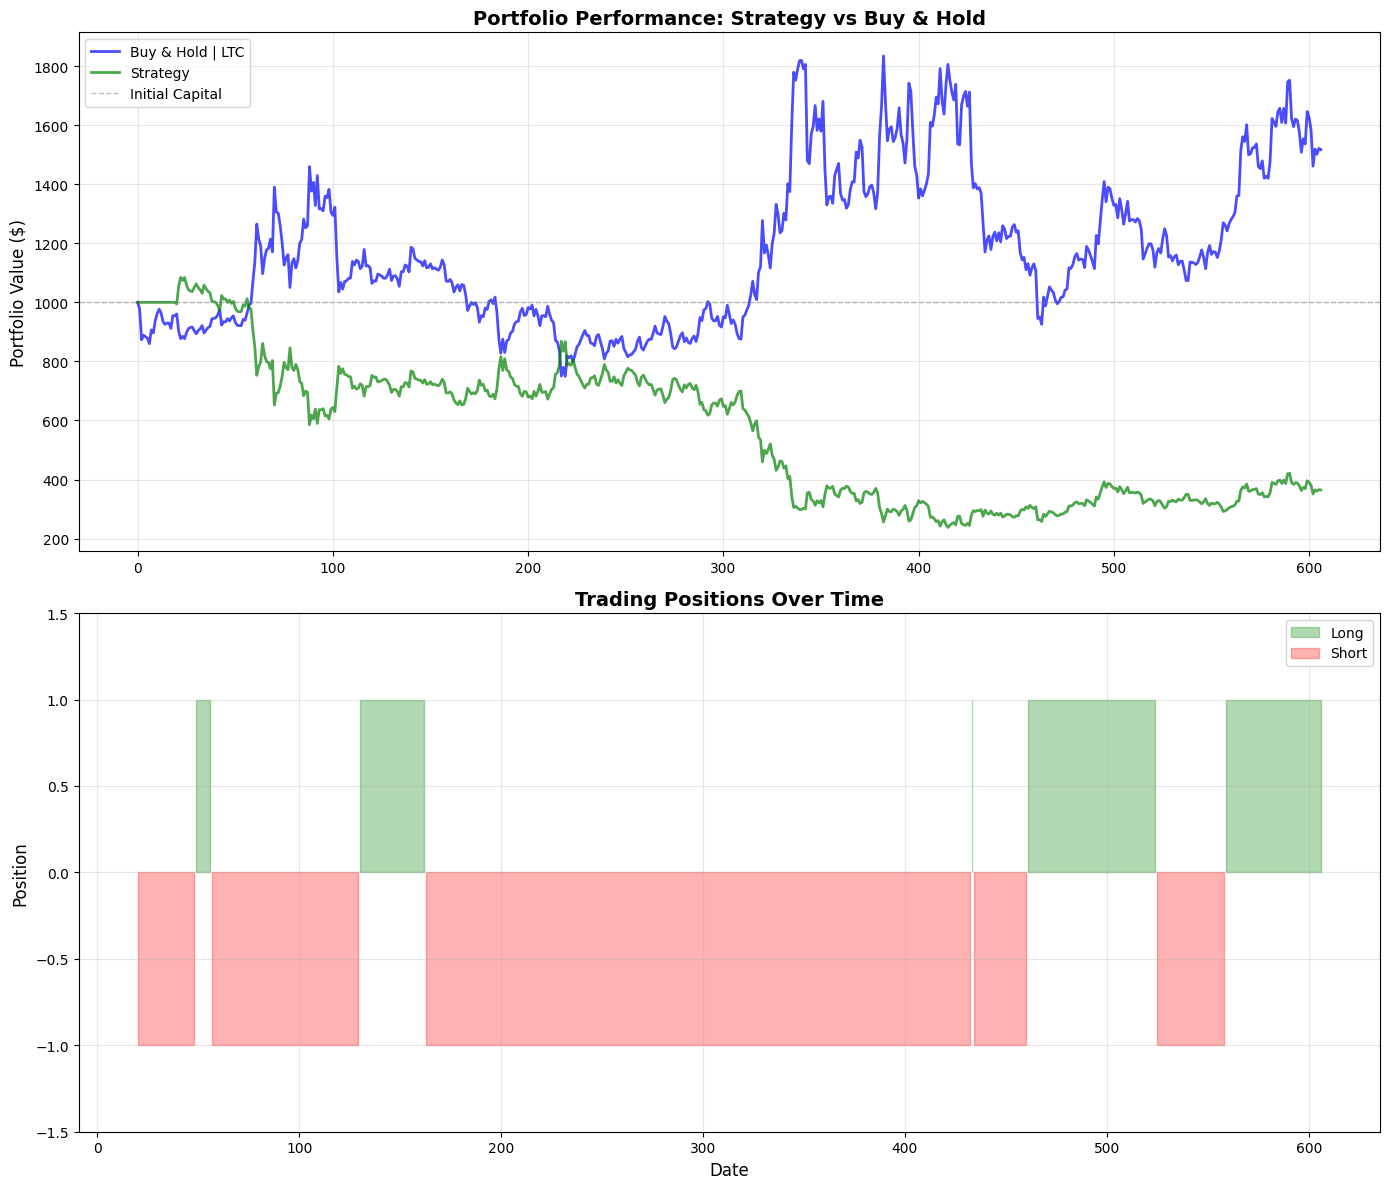

In [1167]:
adx_dfs = {}
for ticker in tickers:
    # df = filter_ticker(ticker=ticker, start=START_DATE, end=END_DATE)
    df = fetch_data(ticker=ticker, start=START_DATE, end=END_DATE)
    df['DMP'] = df['High'].diff()
    df['DMN'] = df['Low'].diff()
    dm_results = df.apply(apply_dm_logic, axis=1)
    df[PLUS_DM] = dm_results['DM_Plus']
    df[MINUS_DM] = dm_results['DM_Minus']
    df['High_Low'] = df['High'] - df['Low']
    df['High_PrevClose'] = abs(df['High'] - df['Close'].shift(1))
    df['Low_PrevClose'] = abs(df['Low'] - df['Close'].shift(1))
    df[TR] = df[['High_Low', 'High_PrevClose', 'Low_PrevClose']].max(axis=1)
    df[ATR] = df[TR].rolling(window=ADX_LOOKBACK).mean()
    df[SMA_PLUS_DM] = df[PLUS_DM].rolling(window=ADX_LOOKBACK).mean()
    df[SMA_MINUS_DM] = df[MINUS_DM].rolling(window=ADX_LOOKBACK).mean()
    df[PLUS_DI] = df[SMA_PLUS_DM] / df[ATR] * 100
    df[MINUS_DI] = df[SMA_MINUS_DM] / df[ATR] * 100
    df[DX] = abs(df[PLUS_DI] - df[MINUS_DI])/abs(df[PLUS_DI] + df[MINUS_DI]) * 100
    df[ADX] = df[DX].rolling(window=ADX_LOOKBACK).mean()
    df[MARKET_STATE] = np.where(df[ADX] > THETA_ADX, 'trending', 'sideways')
    df[SMA_SHORT] = df['Close'].rolling(window=SMA_SHORT_LB).mean()
    df[SMA_LONG] = df['Close'].rolling(window=SMA_LONG_LB).mean()
    df[SMA_SIGNAL] = np.where(df[SMA_SHORT] > df[SMA_LONG], 1, 0)
    df[SMA_CROSSOVER] = df[SMA_SIGNAL].diff()
    df[RETURN] = df['Close'].pct_change() * 100
    df[GAIN] = np.maximum(df[RETURN], 0) * 100
    df[LOSS] = np.maximum(-df[RETURN], 0) * 100
    df[AVERAGE_GAIN] = df[GAIN].rolling(window=RSI_LOOKBACK).mean()
    df[AVERAGE_LOSS] = df[LOSS].rolling(window=RSI_LOOKBACK).mean()
    df[RS] = df[AVERAGE_GAIN] / df[AVERAGE_LOSS]
    df[RSI] = 100 - 100 / (1 + df[RS])
    conditions = [df[RSI] > 70, df[RSI] < 30]
    choices =    [      -1      ,       +1      ]
    df[RSI_SIGNAL] = np.select(conditions, choices, default=0)
    df['RSI-Crossover-temp'] = df[RSI_SIGNAL].diff()
    df[RSI_CROSSOVER] = np.where(df[RSI_SIGNAL] != 0, df['RSI-Crossover-temp'], 0)
    df[FINAL_STRATEGY] = np.where(df[MARKET_STATE] == 'trending', df[SMA_CROSSOVER], df[RSI_CROSSOVER])
    signals = df[FINAL_STRATEGY].values
    returns = df[RETURN].values
    current_position = 0
    positions = np.zeros(len(signals))
    for i in range(len(signals)):
        if signals[i] == 1: 
            current_position = 1
        elif signals[i] == -1:
            current_position = -1
        positions[i] = current_position

    df[POSITION] = positions
    df[STRATEGY_RETURN] = df[POSITION] * df[RETURN]
    df[STRATEGY_RETURN] = df[STRATEGY_RETURN].fillna(0)
    portfolio_values = np.zeros(len(df) + 1)
    portfolio_values[0] = INITIAL_ASSET

    for i in range(len(df)):
        portfolio_values[i + 1] = portfolio_values[i] * (1 + df[STRATEGY_RETURN].iloc[i] / 100)

    df[PORTFOLIO] = portfolio_values[1:]
    df[MARKET_RETURN] = INITIAL_ASSET * (1 + df[RETURN] / 100).cumprod()
    df.loc[0, MARKET_RETURN] = INITIAL_ASSET
    
    print(f"Reporting {ticker}")
    report_adx(df)
    
    df = df.drop(columns=[
        'DMP', 'DMN',
        'High_Low', 'High_PrevClose', 'Low_PrevClose',
        'RSI-Crossover-temp',
    ])
    df.fillna(0)
    adx_dfs[ticker] = df
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 12))

    ax1 = axes[0]
    ax1.plot(df.index, df[MARKET_RETURN], 
            label=f'Buy & Hold | {ticker}', linewidth=2, alpha=0.7, color='blue')
    ax1.plot(df.index, df[PORTFOLIO], 
            label='Strategy', linewidth=2, alpha=0.7, color='green')
    ax1.axhline(y=INITIAL_ASSET, color='gray', linestyle='--', 
                linewidth=1, alpha=0.5, label='Initial Capital')
    ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
    ax1.set_title('Portfolio Performance: Strategy vs Buy & Hold', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Plot 3: Position Over Time
    ax3 = axes[1]
    ax3.fill_between(df.index, 0, df[POSITION], 
                    where=(df[POSITION] > 0), alpha=0.3, color='green', label='Long')
    ax3.fill_between(df.index, 0, df[POSITION], 
                    where=(df[POSITION] < 0), alpha=0.3, color='red', label='Short')
    ax3.set_ylabel('Position', fontsize=12)
    ax3.set_xlabel('Date', fontsize=12)
    ax3.set_title('Trading Positions Over Time', fontsize=14, fontweight='bold')
    ax3.set_ylim([-1.5, 1.5])
    ax3.legend(loc='best', fontsize=10)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.show()

MULTI-STRATEGY PORTFOLIO OPTIMIZATION

1. Organizing data by strategy...
   ADX tickers: ['BTC', 'ETH', 'LINK', 'DOGE', 'LTC']
   Martingale tickers: ['DOGE', 'LINK', 'LTC', 'ETH', 'BTC']

   Mean Reversion Weights (with signs):
     BTC: +0.0002 (LONG)
     LINK: -0.4016 (SHORT)
     DOGE: -144.6297 (SHORT)
     LTC: +0.5443 (LONG)
     Total Long: 0.5445, Total Short: 145.0313

2. OPTIMIZING ADX STRATEGY

OPTIMIZING ADX STRATEGY PORTFOLIO
ADX Strategy:
  Tickers: ['BTC', 'ETH', 'LINK', 'DOGE', 'LTC']
  Date range: 2024-01-01 00:00:00 to 2025-08-29 00:00:00
  Observations: 607

Asset Statistics for ADX:
  BTC: Return=7.62%, Vol=55.14%, Sharpe=0.14
  ETH: Return=89.77%, Vol=61.13%, Sharpe=1.47
  LINK: Return=6.93%, Vol=76.53%, Sharpe=0.09
  DOGE: Return=-32.00%, Vol=102.26%, Sharpe=-0.31
  LTC: Return=-34.27%, Vol=55.93%, Sharpe=-0.61

ADX Portfolio Optimization Results:
----------------------------------------

Max Sharpe Portfolio:
  Return: 89.77%
  Volatility: 61.13%
  Sharpe: 1.47

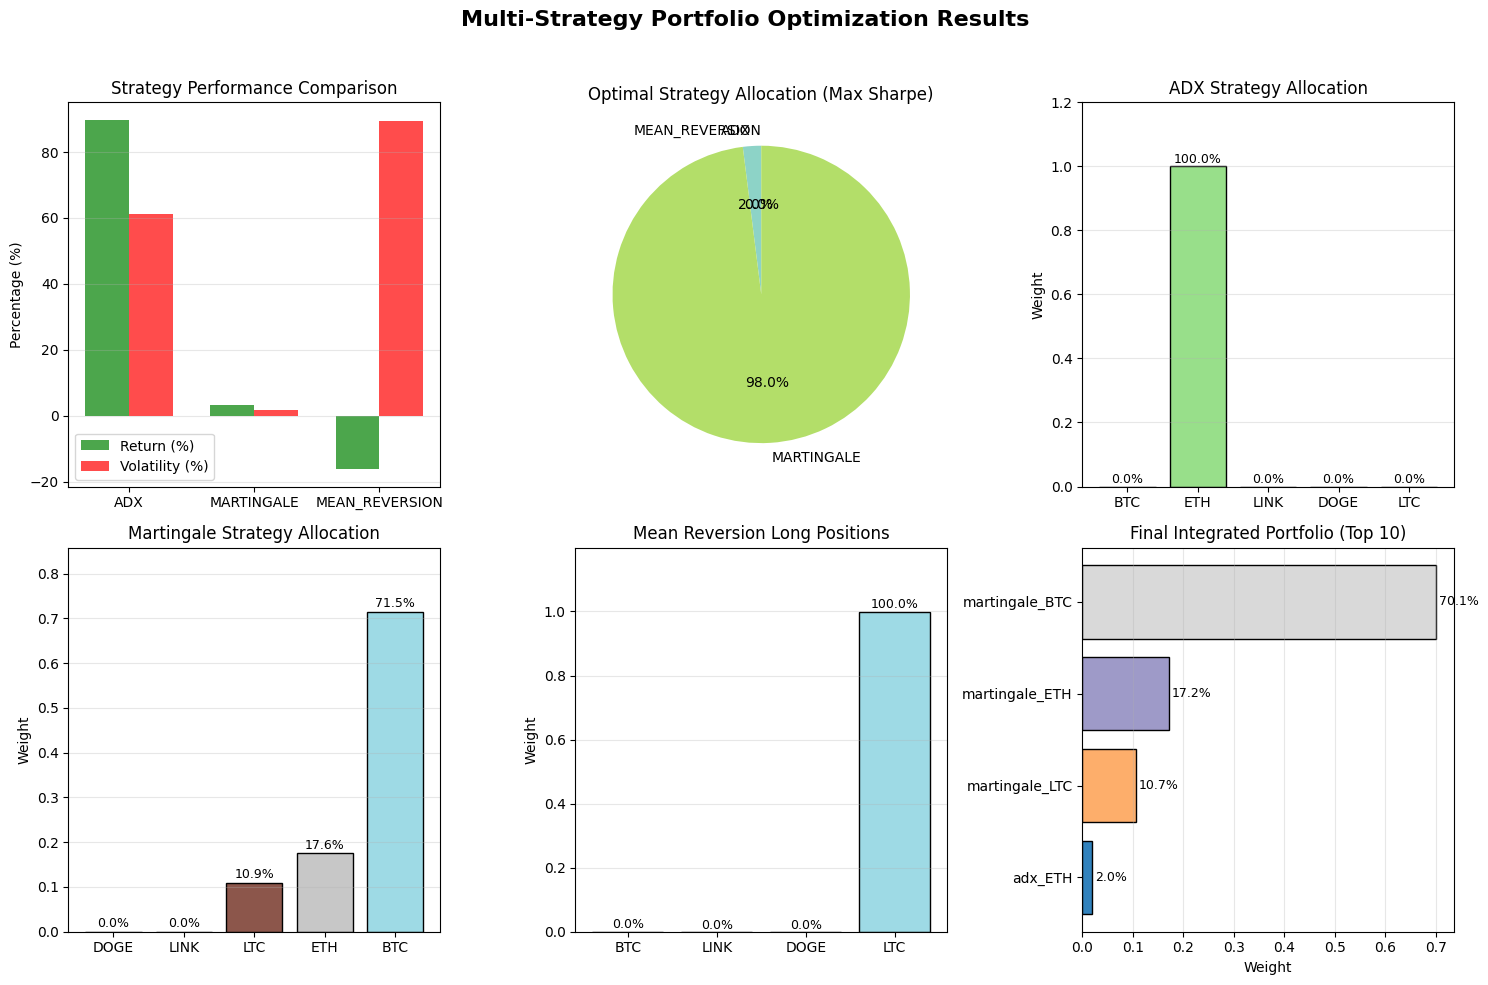


FINAL SUMMARY

Strategy Allocation Summary:
  ADX: 2.0%
  MARTINGALE: 98.0%
  MEAN_REVERSION: 0.0%

DETAILED COMPARISON

ADX vs Martingale Results:
----------------------------------------

ADX Max Sharpe:
  Return: 89.77%
  Volatility: 61.13%
  Sharpe: 1.47
  Weights:
    ETH: 100.0%

Martingale Max Sharpe:
  Return: 3.36%
  Volatility: 1.85%
  Sharpe: 1.82
  Weights:
    LTC: 10.9%
    ETH: 17.6%
    BTC: 71.5%

ACCESSING RESULTS

1. ADX Strategy Max Sharpe Weights:
OrderedDict([('BTC', 0.0), ('ETH', 1.0), ('LINK', 0.0), ('DOGE', 0.0), ('LTC', 0.0)])

2. Master Strategy Allocation:
{'adx': np.float64(0.019821368810751312), 'martingale': np.float64(0.9801786311904834), 'mean_reversion': np.float64(0.0)}

3. Final Integrated Portfolio (first 5):
  adx_ETH: 1.98%
  martingale_LTC: 10.71%
  martingale_ETH: 17.22%
  martingale_BTC: 70.09%


In [1161]:
# Main execution function
def run_complete_optimization(adx_dfs, martingale_dfs, risk_free_rate=0.0):
    """
    Run complete multi-strategy optimization pipeline.
    """
    print(f"{'='*60}")
    print("MULTI-STRATEGY PORTFOLIO OPTIMIZATION")
    print(f"{'='*60}")
    
    # Step 1: Organize data by strategy
    print("\n1. Organizing data by strategy...")
    weights = mean_reversion_bot['weights'].iloc[0].split("*")
    coins = mean_reversion_bot['coin'].iloc[0].split("*")
    strategy_data = {
        'adx': adx_dfs,
        'martingale': martingale_dfs,
        'mean_reversion': {
            'weights': {
                ticker: float(weight) for ticker, weight in zip(coins, weights)  # Keep original sign!
            },
            'tickers': SELECTED_TICKERS
        }
    }
    
    print(f"   ADX tickers: {list(strategy_data['adx'].keys())}")
    print(f"   Martingale tickers: {list(strategy_data['martingale'].keys())}")
    
    # Show mean reversion weights with signs
    print(f"\n   Mean Reversion Weights (with signs):")
    total_long = sum(w for w in strategy_data['mean_reversion']['weights'].values() if w > 0)
    total_short = abs(sum(w for w in strategy_data['mean_reversion']['weights'].values() if w < 0))
    for ticker, weight in strategy_data['mean_reversion']['weights'].items():
        position = "SHORT" if weight < 0 else "LONG"
        print(f"     {ticker}: {weight:+.4f} ({position})")
    print(f"     Total Long: {total_long:.4f}, Total Short: {total_short:.4f}")
    
    # Step 2: Optimize ADX strategy
    print(f"\n{'='*60}")
    print("2. OPTIMIZING ADX STRATEGY")
    print(f"{'='*60}")
    
    adx_results = optimize_single_strategy(
        strategy_data=strategy_data,
        strategy_name='adx',
        tickers=list(strategy_data['adx'].keys()),
        target_return=0.15,
        risk_free_rate=risk_free_rate
    )
    
    # Step 3: Optimize Martingale strategy
    print(f"\n{'='*60}")
    print("3. OPTIMIZING MARTINGALE STRATEGY")
    print(f"{'='*60}")
    
    martingale_results = optimize_single_strategy(
        strategy_data=strategy_data,
        strategy_name='martingale',
        tickers=list(strategy_data['martingale'].keys()),
        target_return=0.15,
        risk_free_rate=risk_free_rate
    )
    
    # Step 4: Analyze Mean Reversion strategy
    print(f"\n{'='*60}")
    print("4. ANALYZING MEAN REVERSION STRATEGY")
    print(f"{'='*60}")
    
    mean_reversion_results = analyze_mean_reversion_strategy(
        strategy_data=strategy_data,
        adx_dfs=adx_dfs,
        risk_free_rate=risk_free_rate
    )
    
    # Combine all results
    all_results = {
        'adx': adx_results,
        'martingale': martingale_results,
        'mean_reversion': mean_reversion_results
    }
    
    # Step 5: Master optimization across strategies
    print(f"\n{'='*60}")
    print("5. MASTER OPTIMIZATION ACROSS STRATEGIES")
    print(f"{'='*60}")
    
    master_results = optimize_across_strategies(
        all_results=all_results,
        target_overall_return=0.12,
        risk_free_rate=risk_free_rate
    )
    
    # Step 6: Create final integrated portfolio
    print(f"\n{'='*60}")
    print("6. CREATING FINAL INTEGRATED PORTFOLIO")
    print(f"{'='*60}")
    
    final_weights = create_final_portfolio(
        all_results=all_results,
        master_results=master_results,
        strategy_allocation='max_sharpe',
        portfolio_type='max_sharpe'
    )
    
    # Step 7: Visualize results
    print(f"\n{'='*60}")
    print("7. VISUALIZING RESULTS")
    print(f"{'='*60}")
    
    plot_optimization_results(all_results, master_results, final_weights)
    
    # Calculate portfolio performance
    print(f"\n{'='*60}")
    print("FINAL SUMMARY")
    print(f"{'='*60}")
    
    print(f"\nStrategy Allocation Summary:")
    for strategy, weight in master_results['portfolios']['max_sharpe']['weights'].items():
        print(f"  {strategy.upper()}: {weight:.1%}")
    
    # Detailed comparison
    print(f"\n{'='*60}")
    print("DETAILED COMPARISON")
    print(f"{'='*60}")
    
    print("\nADX vs Martingale Results:")
    print(f"{'-'*40}")
    
    if adx_results and martingale_results:
        adx_max_sharpe = adx_results['portfolios']['max_sharpe']
        mart_max_sharpe = martingale_results['portfolios']['max_sharpe']
        
        print(f"\nADX Max Sharpe:")
        print(f"  Return: {adx_max_sharpe['performance'][0]:.2%}")
        print(f"  Volatility: {adx_max_sharpe['performance'][1]:.2%}")
        print(f"  Sharpe: {adx_max_sharpe['performance'][2]:.2f}")
        print(f"  Weights:")
        for ticker, weight in adx_max_sharpe['weights'].items():
            if weight > 0.01:
                print(f"    {ticker}: {weight:.1%}")
        
        print(f"\nMartingale Max Sharpe:")
        print(f"  Return: {mart_max_sharpe['performance'][0]:.2%}")
        print(f"  Volatility: {mart_max_sharpe['performance'][1]:.2%}")
        print(f"  Sharpe: {mart_max_sharpe['performance'][2]:.2f}")
        print(f"  Weights:")
        for ticker, weight in mart_max_sharpe['weights'].items():
            if weight > 0.01:
                print(f"    {ticker}: {weight:.1%}")
    
    return {
        'all_results': all_results,
        'master_results': master_results,
        'final_weights': final_weights,
    }


# Update the optimize_single_strategy function to show clearer output
def optimize_single_strategy(strategy_data, strategy_name, tickers=None, 
                           target_return=None, risk_free_rate=0.0):
    """
    Optimize portfolio for a single strategy.
    Returns dictionary with optimization results.
    """
    print(f"\n{'='*60}")
    print(f"OPTIMIZING {strategy_name.upper()} STRATEGY PORTFOLIO")
    print(f"{'='*60}")
    
    # Prepare price data
    price_df = prepare_price_data(strategy_data, strategy_name, tickers)
    
    # Calculate returns
    returns = price_df.pct_change().dropna()
    
    # Calculate expected returns
    mu = expected_returns.mean_historical_return(
        returns, 
        returns_data=True, 
        compounding=True, 
        frequency=252
    )
    
    # Calculate covariance matrix
    monthly_returns = returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
    S = risk_models.sample_cov(
        monthly_returns, 
        returns_data=True, 
        frequency=12
    )
    S = risk_models.fix_nonpositive_semidefinite(S)
    
    # Print asset statistics
    print(f"\nAsset Statistics for {strategy_name.upper()}:")
    for asset in mu.index:
        asset_return = mu[asset]
        asset_vol = np.sqrt(S.loc[asset, asset])
        asset_sharpe = (asset_return - risk_free_rate) / asset_vol
        print(f"  {asset}: Return={asset_return:.2%}, Vol={asset_vol:.2%}, Sharpe={asset_sharpe:.2f}")
    
    # 1. Max Sharpe Portfolio
    ef_sharpe = EfficientFrontier(mu, S, weight_bounds=(0, 1))
    weights_sharpe = ef_sharpe.max_sharpe(risk_free_rate=risk_free_rate)
    perf_sharpe = ef_sharpe.portfolio_performance(
        verbose=False, 
        risk_free_rate=risk_free_rate
    )
    
    # 2. Min Volatility Portfolio
    ef_minvol = EfficientFrontier(mu, S, weight_bounds=(0, 1))
    weights_minvol = ef_minvol.min_volatility()
    perf_minvol = ef_minvol.portfolio_performance(
        verbose=False, 
        risk_free_rate=risk_free_rate
    )
    
    # 3. Target Return Portfolio (if specified)
    if target_return is not None:
        ef_target = EfficientFrontier(mu, S, weight_bounds=(0, 1))
        try:
            weights_target = ef_target.efficient_return(target_return=target_return)
            perf_target = ef_target.portfolio_performance(
                verbose=False, 
                risk_free_rate=risk_free_rate
            )
        except:
            print(f"  Target return {target_return:.1%} not achievable, using Max Sharpe")
            weights_target = weights_sharpe
            perf_target = perf_sharpe
    else:
        weights_target = weights_sharpe
        perf_target = perf_sharpe
    
    # Create results dictionary
    results = {
        'tickers': list(mu.index),
        'price_data': price_df,
        'returns': returns,
        'expected_returns': mu,
        'covariance': S,
        'portfolios': {
            'max_sharpe': {
                'weights': ef_sharpe.clean_weights(),
                'performance': perf_sharpe
            },
            'min_volatility': {
                'weights': ef_minvol.clean_weights(),
                'performance': perf_minvol
            },
            'target_return': {
                'weights': weights_target,
                'performance': perf_target
            }
        }
    }
    
    # Print results with clearer formatting
    print(f"\n{strategy_name.upper()} Portfolio Optimization Results:")
    print(f"{'-'*40}")
    
    print(f"\nMax Sharpe Portfolio:")
    print(f"  Return: {perf_sharpe[0]:.2%}")
    print(f"  Volatility: {perf_sharpe[1]:.2%}")
    print(f"  Sharpe: {perf_sharpe[2]:.2f}")
    print(f"  Asset Weights:")
    for ticker, weight in ef_sharpe.clean_weights().items():
        if weight > 0.01:  # Only show weights > 1%
            print(f"    {ticker}: {weight:.1%}")
    
    print(f"\nMin Volatility Portfolio:")
    print(f"  Return: {perf_minvol[0]:.2%}")
    print(f"  Volatility: {perf_minvol[1]:.2%}")
    print(f"  Sharpe: {perf_minvol[2]:.2f}")
    
    if target_return:
        print(f"\nTarget Return ({target_return:.1%}) Portfolio:")
        print(f"  Return: {perf_target[0]:.2%}")
        print(f"  Volatility: {perf_target[1]:.2%}")
        print(f"  Sharpe: {perf_target[2]:.2f}")
    
    return results


# Also update the analyze_mean_reversion_strategy to handle negative weights properly
def analyze_mean_reversion_strategy(strategy_data, adx_dfs=None, risk_free_rate=0.0):
    """
    Analyze the mean reversion strategy (already has predefined weights).
    """
    print(f"\n{'='*60}")
    print(f"ANALYZING MEAN REVERSION STRATEGY")
    print(f"{'='*60}")
    
    if 'mean_reversion' not in strategy_data:
        raise ValueError("Mean reversion strategy data not found")
    
    mr_data = strategy_data['mean_reversion']
    
    if 'weights' not in mr_data:
        raise ValueError("Mean reversion strategy must have 'weights' dictionary")
    
    weights = mr_data['weights']
    tickers = list(weights.keys())
    
    print(f"Tickers: {tickers}")
    print(f"Predefined Weights (negative = short):")
    
    # Separate long and short positions
    long_positions = {k: v for k, v in weights.items() if v > 0}
    short_positions = {k: abs(v) for k, v in weights.items() if v < 0}
    
    if long_positions:
        print(f"  Long Positions:")
        for asset, weight in long_positions.items():
            print(f"    {asset}: {weight:.4f}")
    
    if short_positions:
        print(f"  Short Positions:")
        for asset, weight in short_positions.items():
            print(f"    {asset}: {weight:.4f}")
    
    # Calculate exposures
    total_long = sum(long_positions.values())
    total_short = sum(short_positions.values())
    net_exposure = total_long - total_short
    gross_exposure = total_long + total_short
    
    print(f"\n  Portfolio Exposures:")
    print(f"    Total Long: {total_long:.4f}")
    print(f"    Total Short: {total_short:.4f}")
    print(f"    Net Exposure: {net_exposure:.4f}")
    print(f"    Gross Exposure: {gross_exposure:.4f}")
    
    # Calculate portfolio performance using available data
    price_series_list = []
    
    for ticker in tickers:
        # Try to find this ticker in any strategy
        found = False
        
        # First check if we have separate adx_dfs
        if adx_dfs is not None and ticker in adx_dfs:
            df = adx_dfs[ticker].copy()
            found = True
        else:
            # Check in strategy data
            for strategy in ['adx', 'martingale']:
                if strategy in strategy_data and ticker in strategy_data[strategy]:
                    df = strategy_data[strategy][ticker].copy()
                    found = True
                    break
        
        if found:
            if 'Date' in df.columns:
                df['Date'] = pd.to_datetime(df['Date'])
                df.set_index('Date', inplace=True)
            
            if 'portfolio' in df.columns:
                price_series = df['portfolio'].rename(ticker)
                price_series_list.append(price_series)
        else:
            print(f"Warning: No price data found for {ticker} in mean reversion strategy")
    
    if not price_series_list:
        print("No price data available for mean reversion analysis")
        return None


    # Combine price data
    price_df = pd.concat(price_series_list, axis=1).dropna()
    
    # Calculate returns
    returns = price_df.pct_change().dropna()
    
    # Calculate portfolio returns based on weights
    available_tickers = price_df.columns.tolist()
    aligned_weights = {ticker: weights.get(ticker, 0) for ticker in available_tickers}
    long_total = sum(v for v in aligned_weights.values() if v > 0)
    short_total = sum(abs(v) for v in aligned_weights.values() if v < 0)

    normalized_weights = {}
    for ticker, w in aligned_weights.items():
        if w > 0:
            normalized_weights[ticker] = w / long_total
        elif w < 0:
            normalized_weights[ticker] = w / short_total  # keep negative
        else:
            normalized_weights[ticker] = 0.0
    weight_array = np.array([normalized_weights[ticker] for ticker in available_tickers])
    portfolio_returns = returns.dot(weight_array)
    annual_return = (1 + portfolio_returns.mean())**252 - 1
    annual_vol = portfolio_returns.std() * np.sqrt(252)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_vol if annual_vol > 0 else 0

    print(f"\nAligned Weights (based on available data):")
    for ticker, weight in normalized_weights.items():
        if weight != 0:
            position = "SHORT" if weight < 0 else "LONG"
            print(f"  {ticker}: {weight:+.4f} ({position})")
    
    # Calculate portfolio statistics
    if len(returns) > 0:
        # Daily portfolio returns
        weight_values = np.array([normalized_weights[ticker] for ticker in available_tickers])
        portfolio_returns = returns.dot(weight_values)
        
        # Annualized statistics
        annual_return = (1 + portfolio_returns.mean())**252 - 1
        annual_vol = portfolio_returns.std() * np.sqrt(252)
        sharpe_ratio = (annual_return - risk_free_rate) / annual_vol if annual_vol > 0 else 0
        
        # Create results dictionary
        results = {
            'tickers': available_tickers,
            'price_data': price_df,
            'returns': returns,
            'portfolio_returns': portfolio_returns,
            'weights': normalized_weights,
            'performance': (annual_return, annual_vol, sharpe_ratio),
            'exposures': {
                'long': total_long,
                'short': total_short,
                'net': net_exposure,
                'gross': gross_exposure
            }
        }
        
        print(f"\nMean Reversion Strategy Performance:")
        print(f"  Annual Return: {annual_return:.2%}")
        print(f"  Annual Volatility: {annual_vol:.2%}")
        print(f"  Sharpe Ratio: {sharpe_ratio:.2f}")
        
        return results
    
    return None

# Example usage
if __name__ == "__main__":
    # Assuming adx_dfs is your dictionary of DataFrames
    # adx_dfs = {'BTC': df_btc, 'ETH': df_eth, ...}
    
    # Run complete optimization
    optimization_results = run_complete_optimization(
        adx_dfs=adx_dfs,  # Your data dictionary
        martingale_dfs=martingale_dfs,
        risk_free_rate=0.0
    )
    
    # Access individual results
    print(f"\n{'='*60}")
    print("ACCESSING RESULTS")
    print(f"{'='*60}")
    
    print("\n1. ADX Strategy Max Sharpe Weights:")
    print(optimization_results['all_results']['adx']['portfolios']['max_sharpe']['weights'])
    
    print("\n2. Master Strategy Allocation:")
    print(optimization_results['master_results']['portfolios']['max_sharpe']['weights'])
    
    print("\n3. Final Integrated Portfolio (first 5):")
    final_items = list(optimization_results['final_weights'].items())[:5]
    for asset, weight in final_items:
        print(f"  {asset}: {weight:.2%}")